# Paper annual cycle plots

With physics + Arctic snow code modifications v1 (subli correct v2)

In [6]:
# Env: sc2_v0
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy import stats
import xesmf as xe # For regridding (https://xesmf.readthedocs.io/en/latest/)
import calendar
import os

In [7]:
# https://www.w3schools.com/python/python_classes.asp

class Site:
  def __init__(self, name, long_name, location, lat, lon, elevation, period, start, stop, period_used, run):
    self.name = name
    self.long_name = long_name
    self.location = location
    self.lat = lat
    self.lon = lon
    self.elevation = elevation
    self.period = period
    self.start = start
    self.stop = stop
    self.period_used = period_used
    self.run = run

exps = [
    'DEF',
    # 'BUG_CORRECT',
    # 'BUG_CORRECT_TSNBT_OP1',
    'BUG_CORRECT_TSNBT_OP1_EZERO',
    # 'PHYS_ALL_SUBLI_CORRECT',
    'PHYS_ALL_SUBLI_v2',
    # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne', # Best without TVC (COMPACT_2.5)
    'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne', # best with TVC

]

# SnowMIP
cdp = Site('cdp', 'Col de Porte, France', '45.30°N, 5.77°E', 45.30, 5.77, '1325 m', 
           '1 October 1994 to 30 September 2014', '1994-10-01', '2014-09-30', slice('1994-10-01', '2014-09-30'), exps)

rme = Site('rme', 'Reynolds Mountain East, Idaho, USA', '43.19°N, 116.78°W', 43.19, -116.78, '2060 m', 
           '1 October 1988 to 30 September 2008', '1988-10-01', '2008-09-30', slice('1988-10-01', '2008-09-30'), exps)

snb = Site('snb', 'Senator Beck, Colorado, US', '37.91°N, 107.73°W', 37.91, -107.73, '3714 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

swa = Site('swa', 'Swamp Angel, Colorado, USA', '37.91°N, 107.71°W', 37.91, -107.71, '3371 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

sap = Site('sap', 'Sapporo, Japan', '43.08°N, 141.34°E', 43.08, 141.34, '15 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

sod = Site('sod', 'Sodankylä, Finland', '67.37°N, 26.63°E', 67.37, 26.63, '179 m', 
           '1 October 2007 to 30 September 2014', '2007-10-01', '2014-09-30', slice('2007-10-01', '2014-09-30'), exps)

wfj = Site('wfj', 'Weissfluhjoch, Switzerland', '46.83°N, 9.81°E', 46.83, 9.81, '2540 m', 
           '1 September 1996 to 31 August 2016', '1996-10-01', '2016-08-31', slice('1996-10-01', '2016-08-31'), exps)

# Arctic 
byl = Site('byl', 'Bylot Island, Canadian high Arctic', '73.15°N, 80.00°W', 73.15, -80.00, '25 m', 
           '11 July 2013 to 25 June 2019', '2013-07-11', '2019-06-25', slice('2014-07-11', '2019-06-25'), 
           [
               'peat_DEF',
               # 'peat_BUG_CORRECT',
               # 'peat_BUG_CORRECT_TSNBT_OP1',
               'peat_BUG_CORRECT_TSNBT_OP1_EZERO',
               # 'peat_PHYS_ALL_SUBLI_CORRECT',
               'peat_PHYS_ALL_SUBLI_v2',
               # 'peat_PHYS_ALL_SUBLI_CORRECT_COMPAC',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne',
           ])

umt = Site('umt', 'Umiujaq TUNDRA, northeastern Canada', '56.55877°N, 76.48234°W', 56.55877, -76.48234, '132 m', 
           '28 Sept 2012 to 15 October 2021', '2012-09-28', '2021-10-15', slice('2016-09-01', '2021-08-31'), 
           [
               'DEF_correct_SH',
               # 'BUG_CORRECT',
               # 'BUG_CORRECT_TSNBT_OP1',
               'BUG_CORRECT_TSNBT_OP1_EZERO_correct_SH',
               # 'PHYS_ALL_SUBLI_CORRECT',
               'PHYS_ALL_SUBLI_v2_correct_SH',
               # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
               'PHYS_ALL_SUBLI_v2_COMPAC_v1_correct_SH',
               'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne_correct_SH',
               'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH',
           ])


tvc = Site('tvc', 'Trail Valley Creak, northwestern Canada', '68.74617°N, 133.50171°W', 68.74617, -133.50171, '85 m', 
           '01 Oct 2017 to 30 Sept 2019', '2017-10-01', '2019-09-30', slice('2017-10-01', '2019-09-30'), 
           [
               '1peat_2xSnowf_DEF_correct_SH',
               # '1peat_2xSnowfBUG_CORRECT',
               # '1peat_2xSnowfBUG_CORRECT_TSNBT_OP1',
               '1peat_2xSnowf_BUG_CORRECT_TSNBT_OP1_EZERO_correct_SH',
               # '1peat_2xSnowf_PHYS_ALL_SUBLI_CORRECT',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_correct_SH',
               # '1peat_2xSnowf_PHYS_ALL_SUBLI_CORRECT_COMPAC',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1_correct_SH',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne_correct_SH',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH',
           ])

# umf = Site('umf', 'Umiujaq FOREST, northeastern Canada', '56.55308°N, 76.47258°W', 56.55308, -76.47258, '82 m', 
#            '26 Nov 2015 to 19 October 2021', '2015-11-26', '2021-10-19', slice('2018-09-01', '2021-08-31'), 
#            ['Ref', 'EZERO'])


In [8]:
SnowMIP_sites = [cdp, rme, snb, swa, sap, sod, wfj]
# SnowMIP_sites = [cdp, rme, snb, sap, sod, wfj]
SnowArctic_sites = [byl, umt, tvc]

path_SnowMIP = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowMIP/'
path_SnowArctic = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowArctic/'
path_Paul = '/home/mickael-lalande/Dropbox/data/SnowMIP/Paul/CLASS_Results'

ds_d_SnowMIP_list = []
for i, exp in enumerate(exps):
    paths_SnowMIP = [path_SnowMIP+site.name+'/'+'run_'+exp for site in SnowMIP_sites]
    # Change the syntax as the ref run is not necessarily having the same name for all sites
    paths_SnowArctic = [path_SnowArctic+site.name+'/'+'run_'+site.run[i] for site in SnowArctic_sites]
    paths = paths_SnowMIP + paths_SnowArctic
    ds_d_SnowMIP_list.append([xr.open_mfdataset(path+'/*_daily.nc').squeeze().load() for path in paths])


# ds_d_Paul_list = []
# for site in SnowMIP_sites:
#     df_Paul = pd.read_csv(path_Paul+'/CLASS_sv_REF_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.txt', delim_whitespace=True)
#     df_Paul.index = pd.to_datetime(df_Paul[['year', 'month', 'day', 'hour']]).values
#     df_Paul= df_Paul.drop(columns=['year', 'month', 'day', 'hour'])
#     df_Paul.albs = df_Paul.albs.replace({0 : np.nan})
#     df_Paul.albs = df_Paul.albs.replace({0 : np.nan})
#     df_Paul.tsn = df_Paul.tsn.replace({-999 : np.nan})
#     df_Paul.tsns = df_Paul.tsns.replace({-999 : np.nan})
#     ds_Paul_h = df_Paul.to_xarray()
#     ds_Paul_h = ds_Paul_h.rename({'index': 'time'})
#     ds_Paul_d = ds_Paul_h.resample(time='D').mean().load()
#     ds_Paul_d = ds_Paul_d.assign_coords(layer=[0.05 , 0.225, 2.225]) # center of Paul's soil layers (DELZ = [0.1, 0.25, 3.75])
    

#     # Combine the Soil temperature in one variable
#     ds_Paul_d = ds_Paul_d.assign(
#         tsl=(('layer', 'time'), [
#             list(ds_Paul_d['tsl:1'].values),
#             list(ds_Paul_d['tsl:2'].values),
#             list(ds_Paul_d['tsl:3'].values),
#         ])
#     )
        
#     ds_d_Paul_list.append(ds_Paul_d)

## Set soil levels

In [9]:
path = "/home/mickael-lalande/eccc/classic-develop/inputFiles/SnowMIP/cdp"
rsfile = xr.open_dataset(path+'/rsfile_spinup-final_Ref.nc')

In [10]:
def assign_center_depth(ds, rsfile):
    layer_c = []
    for i in range(len(rsfile.DELZ)):
        if i == 0:
            layer_c.append(rsfile.DELZ.cumsum().values[i]/2)
        else:
            layer_c.append(rsfile.DELZ.cumsum().values[i-1] + rsfile.DELZ.values[i]/2)
    with xr.set_options(keep_attrs=True):
        ds = ds.assign_coords(layer=ds.layer*0+layer_c)
    return ds

In [11]:
for i, exp in enumerate(exps):
    for j in range(len(SnowMIP_sites+SnowArctic_sites)):
        ds_d_SnowMIP_list[i][j] = assign_center_depth(ds_d_SnowMIP_list[i][j], rsfile)

## Convert noleap year cftime to datetime

In [12]:
for i in range(len(tvc.run)):
    ds_d_SnowMIP_list[i][-1]['time'] = pd.to_datetime(ds_d_SnowMIP_list[i][-1].indexes['time'].to_datetimeindex())
    ds_d_SnowMIP_list[i][-1] = ds_d_SnowMIP_list[i][-1].reindex(
        time=pd.date_range(
            ds_d_SnowMIP_list[i][-1]['time'][0].values, 
            ds_d_SnowMIP_list[i][-1]['time'][-1].values
        )
    )

## Compare with obs

In [13]:
path_menard2019 = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all'

ds_d_Obs_list = []
for site in SnowMIP_sites:
    ds_h_eval_menard2019 = xr.open_dataset(path_menard2019+'/obs_insitu_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.nc')
    ds_d_eval_menard2019 = ds_h_eval_menard2019.resample(time='D').mean().load()
    ds_d_Obs_list.append(ds_d_eval_menard2019)

In [14]:
path_obs_byl = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Bylot'
path_obs_umt = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'
# path_obs_umf = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'
path_obs_tvc = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/TVC/TVCSnowCLM/TVCMetData'

# path_obs_list = [path_obs_byl, path_obs_umt, path_obs_umf]
path_obs_list = [path_obs_byl, path_obs_umt, path_obs_tvc]
for site, path in zip(SnowArctic_sites, path_obs_list):
    ds_h_obs = xr.open_dataset(path+'/obs_insitu_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.nc').load()
    if site.name == 'byl':
        ds_h_obs['albs'] = ds_h_obs.albs.where(ds_h_obs.flag_albs_ERA5 == 0).where(ds_h_obs.albs < 1) # to avoid > 1 albedo values
    if site.name == 'umt':
        ds_h_obs = ds_h_obs.mean(dim='veg') # average over lichen and lowshrub area (tsl)
    if site.name in ['tvc']:
        ds_h_obs['snd_auto'] = ds_h_obs.snd_auto/100
        ds_h_obs = ds_h_obs.rename({'albedo': 'albs', 'swc': 'mrsll'})
    # Remove albs for Arctic sites (wrong values)
    if site.name in ['byl', 'umt', 'tvc']:
        ds_h_obs = ds_h_obs.drop_vars('albs')
        
    ds_d_obs = ds_h_obs.resample(time='D').mean().load()
    ds_d_Obs_list.append(ds_d_obs)

## Merge Arctic and SnowMIP

In [15]:
# ds_d_Obs_list = ds_d_Obs_list + ds_d_Obs_Arctic_list
# ds_d_SnowMIP_list = ds_d_SnowMIP_list + ds_d_SnowArctic_list

### SD

In [16]:
exps

['DEF',
 'BUG_CORRECT_TSNBT_OP1_EZERO',
 'PHYS_ALL_SUBLI_v2',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
 'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne']

In [17]:
label_exps = ['DEF', 'PHYS', '+ SUBLI', '+ COMPAC', '+ CL11', 'ALL_TVC']

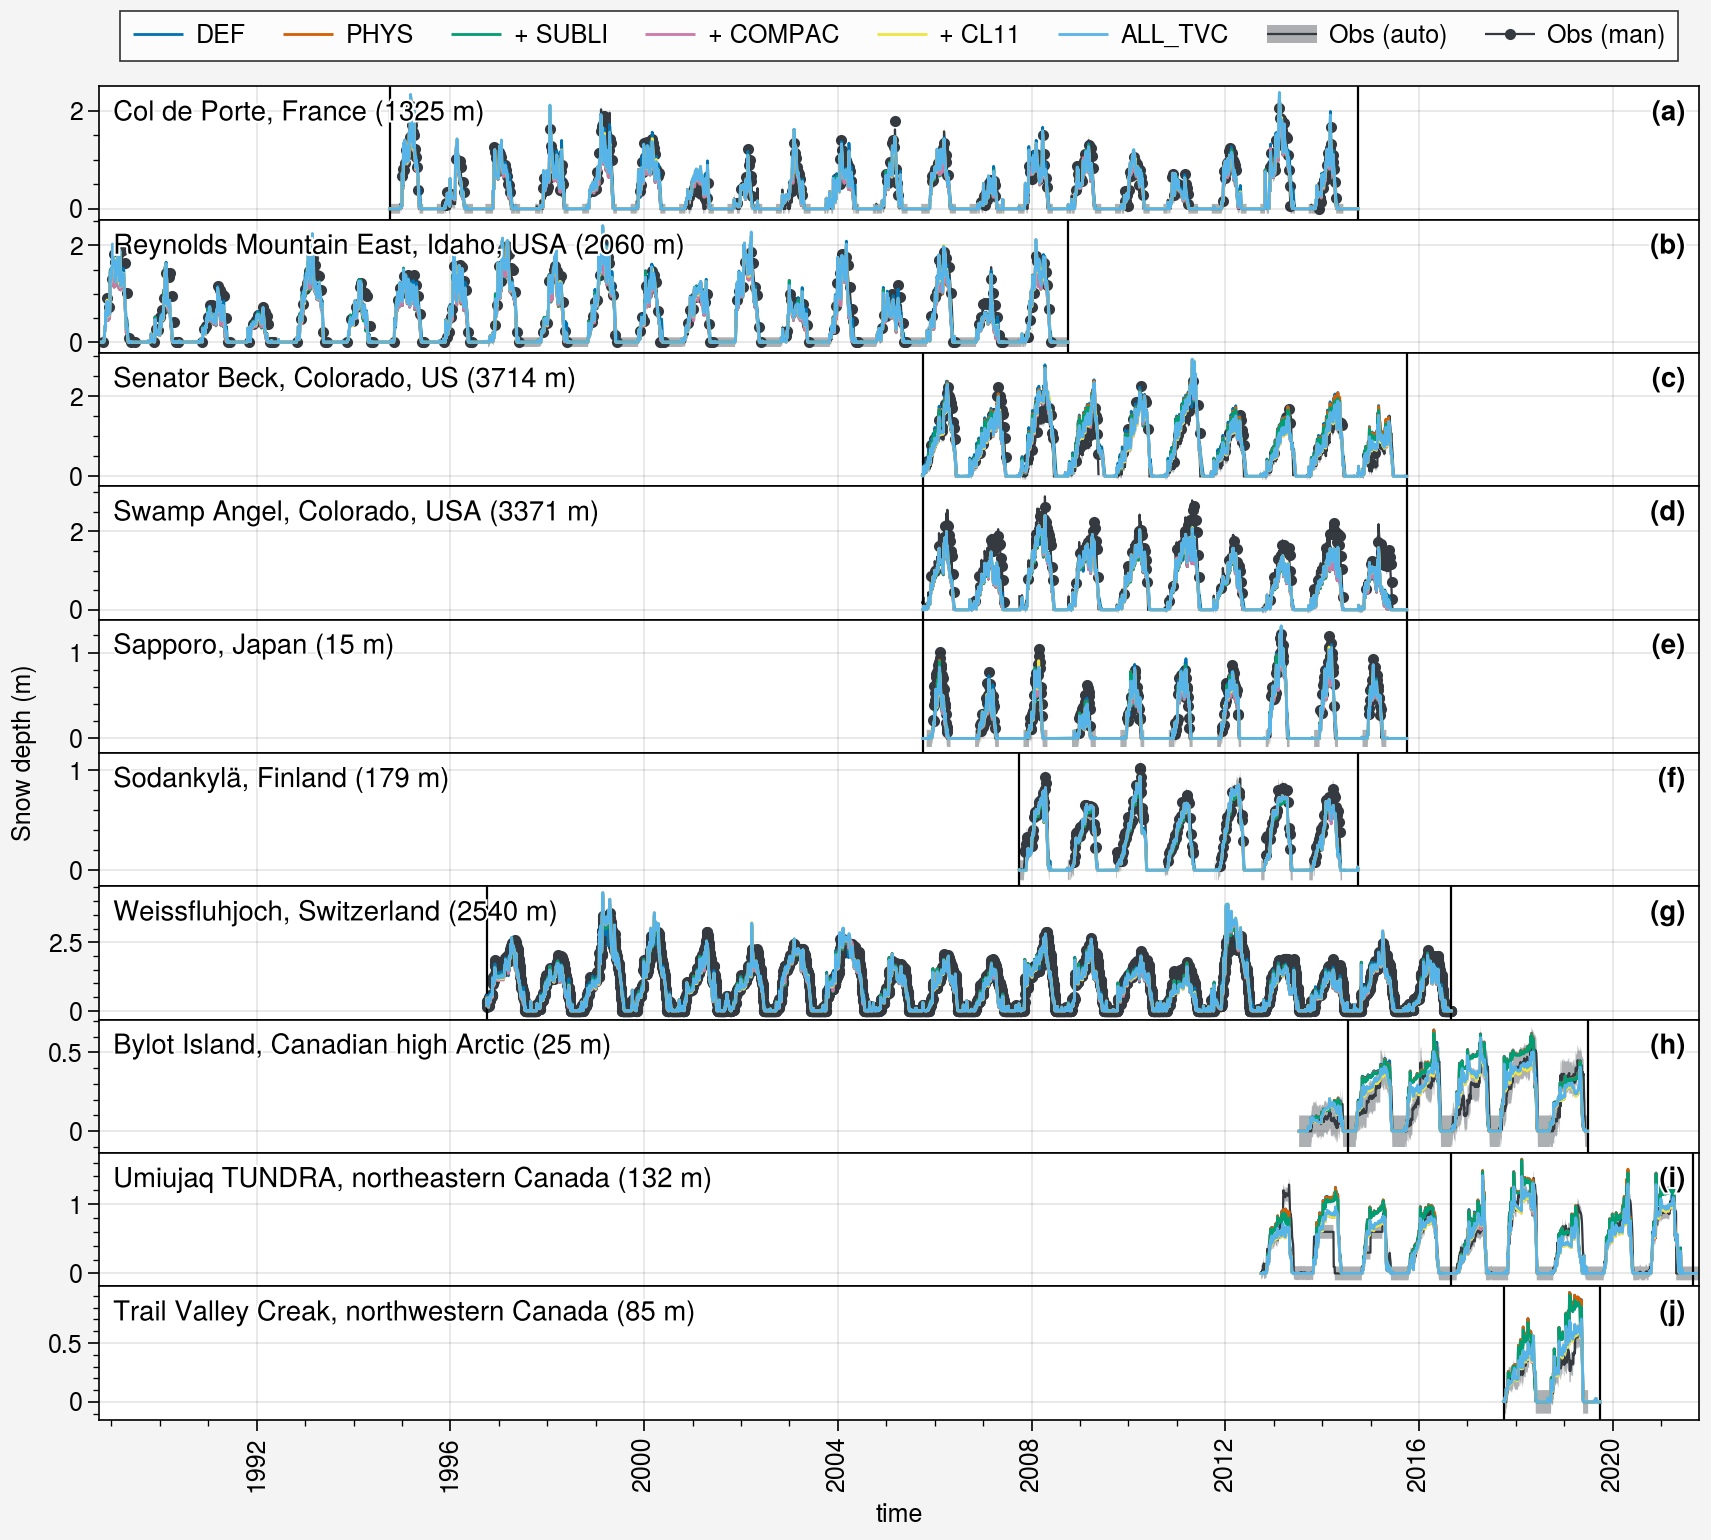

In [18]:
fig, axs = pplt.subplots(nrows=len(SnowMIP_sites+SnowArctic_sites), refaspect=12, refwidth=8, space=0)

color_obs = 'gray8'

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    # Model 
    h_exps = []
    # for j, exp in enumerate(exps): 
    for j, exp in enumerate(label_exps): 
        h = axs[i].plot(ds_d_SnowMIP_list[j][i].snd.sel(time=slice(site.start, site.stop)), label=exp, lw=1)
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = axs[i].plot(ds_d_Paul_list[i].snd.sel(time=slice(site.start, site.stop)), label='CLASS', color='red9', lw=1)
    
    # Obs
    shadedata = np.concatenate((
        np.expand_dims(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)).values+0.1, axis=0),
        np.expand_dims(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)).values-0.1, axis=0),), axis=0)
    h_obs_auto = axs[i].plot(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)), shadedata=shadedata, color=color_obs, 
                zorder=0, lw=0.8, label='Obs (auto)')
    
    if 'snd_man' in list(ds_d_Obs_list[i].keys()):
        h_obs_man = axs[i].plot(ds_d_Obs_list[i].snd_man.sel(time=slice(site.start, site.stop)), marker='.', color=color_obs, 
                    zorder=0, lw=0.8, label='Obs (man)')
    
    axs[i].format(ylabel='Snow depth (m)', ultitle=site.long_name+' ('+site.elevation+')')
    axs[i].vlines(ds_d_SnowMIP_list[j][i].sel(time=site.period_used).time[0], axs[i].get_ylim()[0], axs[i].get_ylim()[1], 
                  color='k', lw=0.8)
    axs[i].vlines(ds_d_SnowMIP_list[j][i].sel(time=site.period_used).time[-1], axs[i].get_ylim()[0], axs[i].get_ylim()[1], 
                  color='k', lw=0.8)
    


# axs[4].legend(ncols=5, loc='ll')
# fig.legend(h_exps+h_paul+h_obs_auto+h_obs_man, ncols=2, loc='t')
fig.legend(h_exps+h_obs_auto+h_obs_man, ncols=8, loc='t')

fig.format(abc='(a)', abcloc='ur')

# fig.suptitle('Col de Porte, France, 1325 m')
# fig.save('img/tn1_sd.jpg')

### Annual cycles

In [19]:
[site.name for site in SnowMIP_sites+SnowArctic_sites]

['cdp', 'rme', 'snb', 'swa', 'sap', 'sod', 'wfj', 'byl', 'umt', 'tvc']

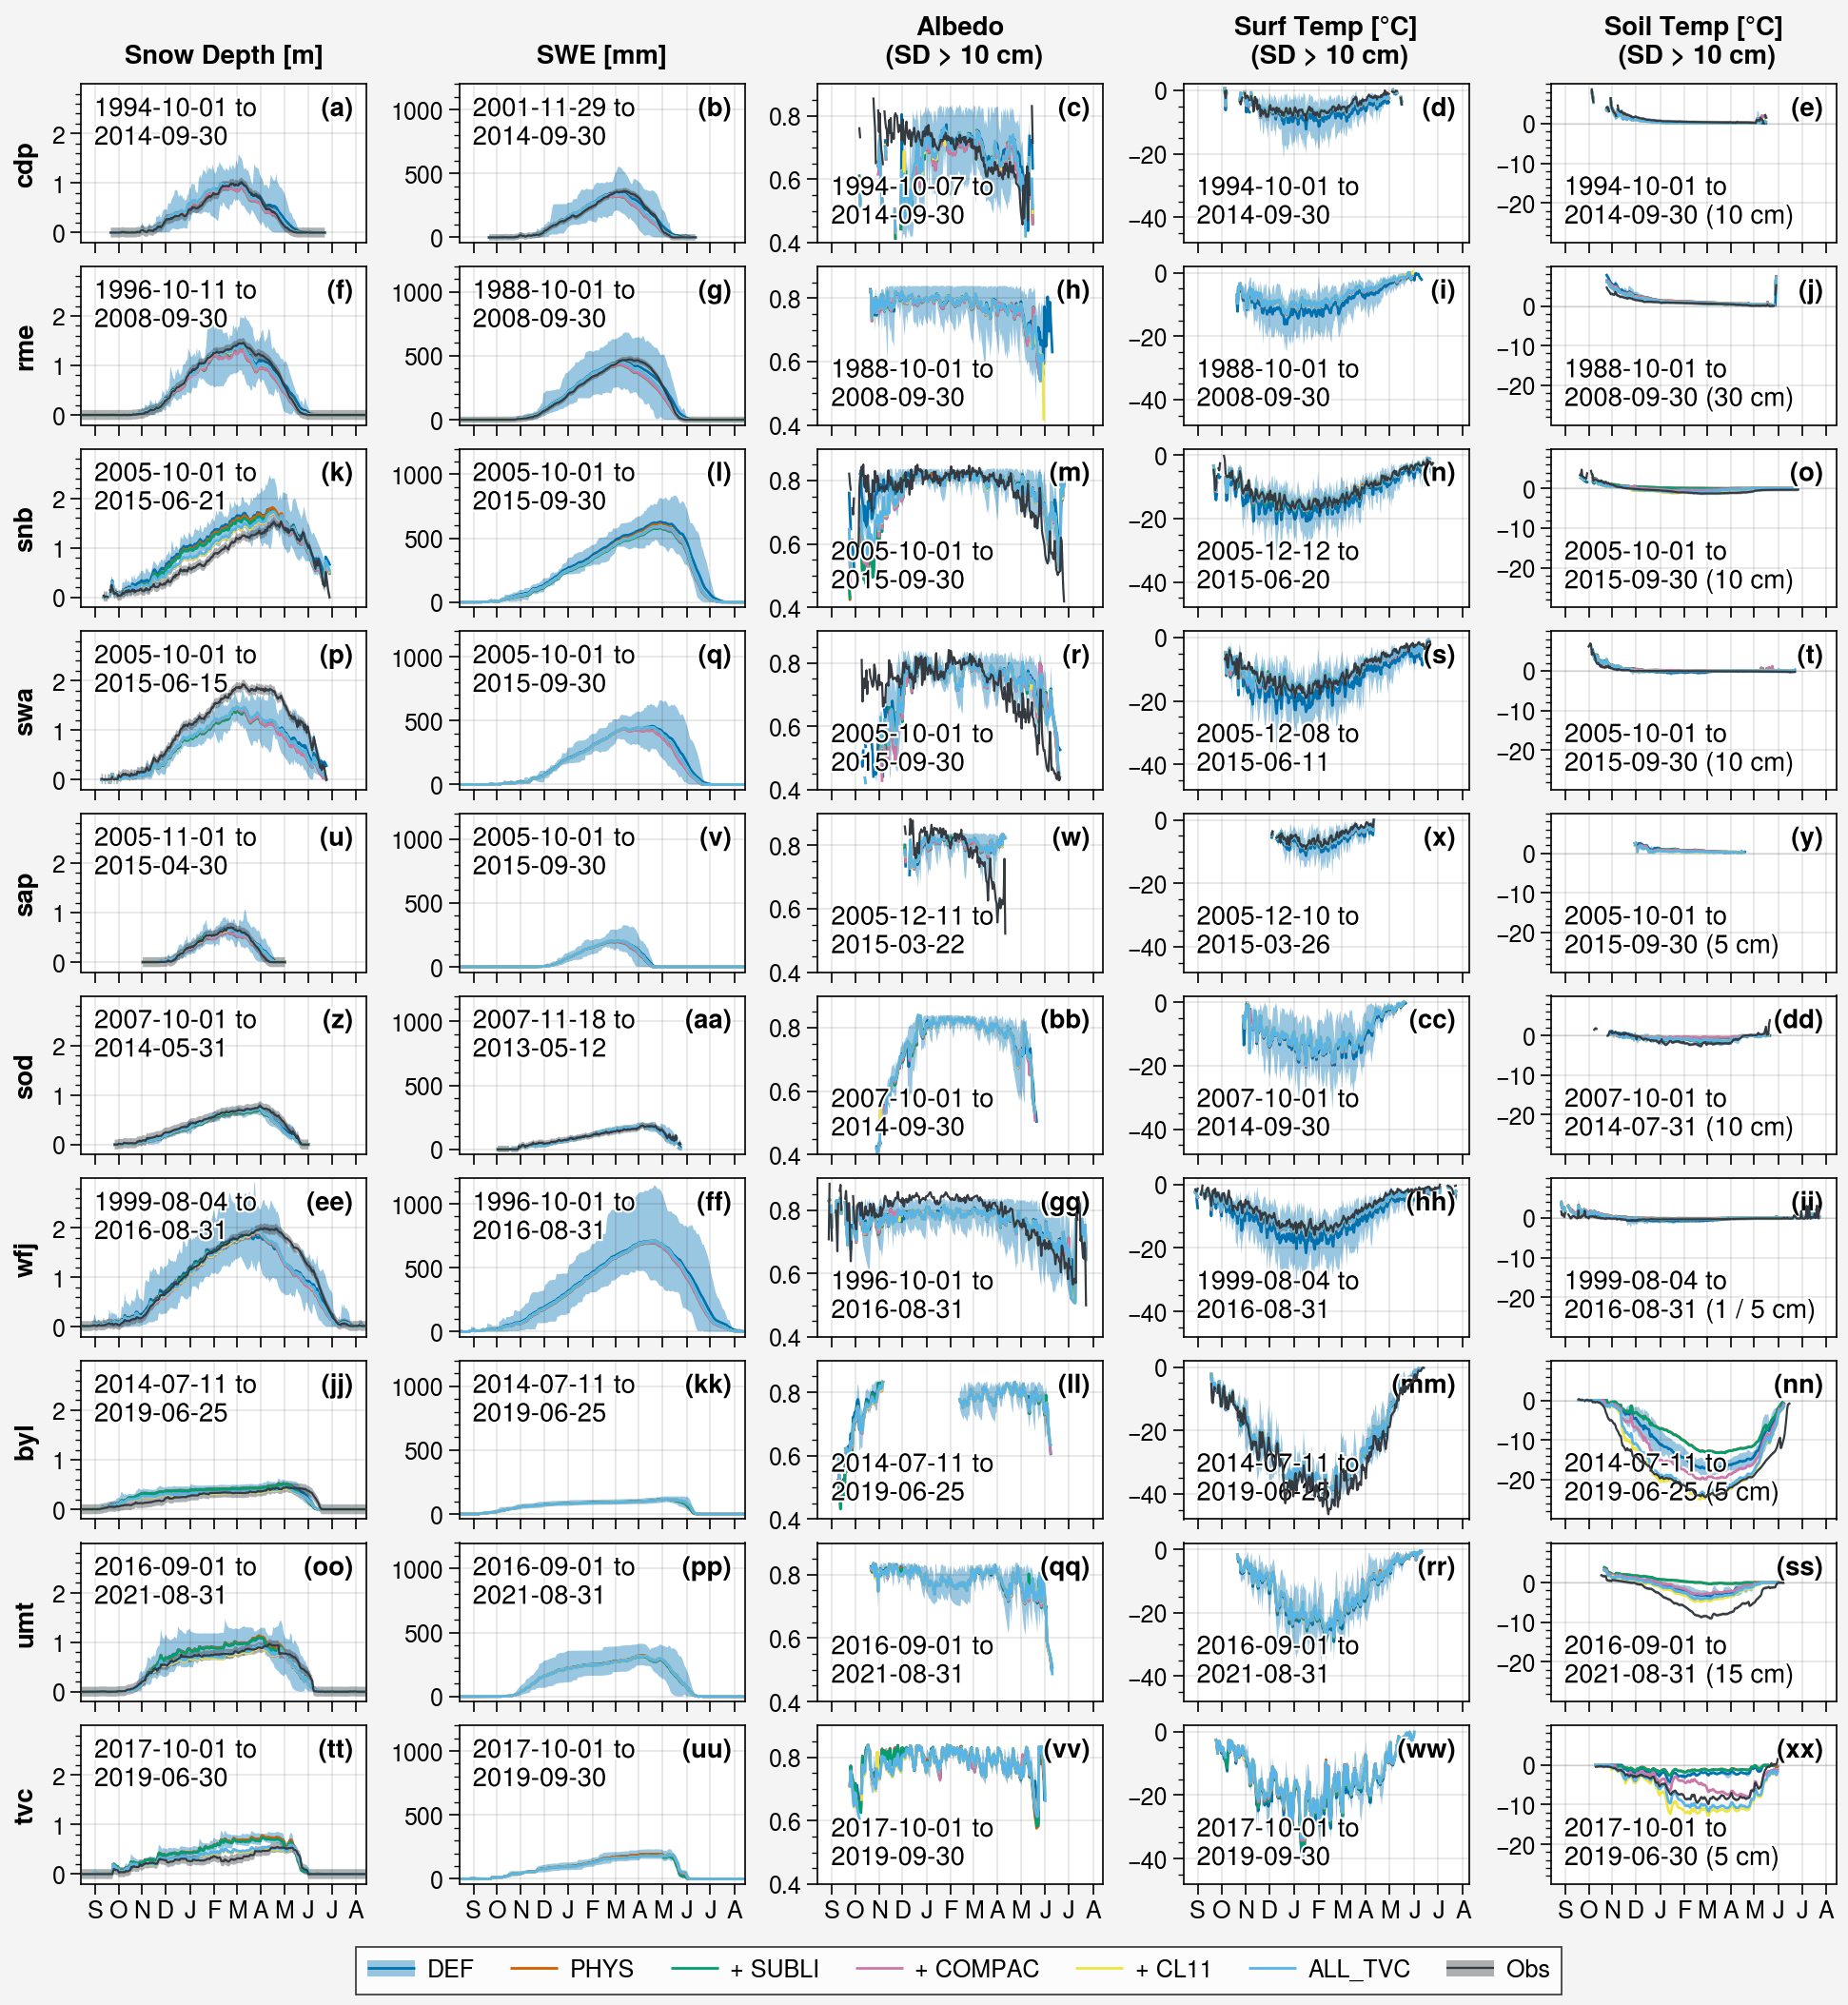

In [20]:
import warnings
warnings.filterwarnings("ignore")

color_obs = 'gray8'

# Shifted DOY tick positions (non-leap year, shift = -140)
# These are the first DOY of each corresponding month in the shifted calendar
xticks = [
    19,   # Sep
    49,   # Oct
    79,   # Nov
    109,  # Dec
    140,  # Jan
    171,  # Feb
    200,  # Mar
    230,  # Apr
    260,  # May
    291,  # Jun
    321,  # Jul
    352   # Aug (closing)
]

# Corresponding month initials
xlabels = ['S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A']

# fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0)
fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0, hspace=1, refaspect=1.8)

# for i, site in enumerate([cdp]):
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):

    doy = 140
    period = site.period_used

    # Snow depth
    ax = axs[i*5+0]
    mask_obs = ~ds_d_Obs_list[i].snd_auto.sel(time=period).isnull()
    
    shadedata = ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
    h1 = ax.plot(ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
    h_exps = []
    for j, exp in enumerate(label_exps[1:]):
        h = ax.plot(ds_d_SnowMIP_list[j+1][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = ax.plot(ds_d_Paul_list[i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
    #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
    
    obs = ds_d_Obs_list[i].snd_auto.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
    shadedata = np.concatenate((np.expand_dims(obs.values+0.1, axis=0), np.expand_dims(obs.values-0.1, axis=0),), axis=0)
    h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.8, zorder=10)
    ax.format(ylabel='', ylim=(-0.2,3), yticks=[0, 1, 2],
              ultitle=str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
              str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[-1].values)[:10])    
    # ax.legend(h1+h_exps+h_paul+h_obs, loc='ul', ncols=1)
    
    # Snow Water Equivalent
    ax = axs[i*5+1]

    if 'snw_auto' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].snw_auto.sel(time=period).isnull()
        
        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        
        obs = ds_d_Obs_list[i].snw_auto.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+25, axis=0), np.expand_dims(obs.values-25, axis=0),), axis=0)
        h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.8, zorder=10)
        ax.format(ylabel='', ylim=(-40,1200),
                  ultitle=str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[-1].values)[:10]) 

    else:
        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        
        ax.format(ylabel='', ylim=(-40,1200), ultitle=period.start+' to\n'+ period.stop)


    # Albedo (need to add a condition albs > 0.4 because a few values are 0 in the model -> bug? (e.g., at Saporo)
    # + low values are observed in the begining of the season (probably due to not full SCF coveraged)
    ax = axs[i*5+2]
    lim_alb = 0.4
    lim_alb_sup = 0.9

    if 'albs' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].albs.where(ds_d_Obs_list[i].albs > lim_alb).where(ds_d_Obs_list[i].albs < lim_alb_sup)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).sel(time=period).isnull()
        
        shadedata = ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                     .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albs.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albs > lim_alb) \
                        .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albs.sel(time=period).where(ds_d_Paul_list[i].albs > lim_alb) \
        #                     .where(ds_d_Paul_list[i].albs < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        if site not in ['umt', 'byl']:
            obs = ds_d_Obs_list[i].albs.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
            h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.8, zorder=10)
            ax.format(ylabel='', ylim=(0.4,0.9),
                      lltitle=str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[-1].values)[:10]) 

    else:
        shadedata = ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albs.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albs > lim_alb) \
                        .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albs.sel(time=period).where(ds_d_Paul_list[i].albs > lim_alb) \
        #                      .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        
        ax.format(ylabel='', ylim=(0.4,0.9), lltitle=period.start+' to\n'+ period.stop)
    
    
    # Surface temperature
    # Add condition on ts <= 0 on obs to avoid melting pachy areas to be counted
    ax = axs[i*5+3]

    if 'ts' in list(ds_d_Obs_list[i].keys()) and ds_d_Obs_list[i].ts.notnull().sum() != 0:
        mask_obs = ~ds_d_Obs_list[i].ts.sel(time=period).where(ds_d_Obs_list[i].ts <= 0)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()
        
        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)
        
        obs = ds_d_Obs_list[i].ts.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.8, zorder=10)
        ax.format(ylabel='', ylim=(-48,2),
                  lltitle=str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[-1].values)[:10]) 

    else:
        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)
        
        ax.format(ylabel='', ylim=(-48,2), lltitle=period.start+' to\n'+ period.stop)

    
    # Soil temperature
    ax = axs[i*5+4]

    if 'tsl' in list(ds_d_Obs_list[i].keys()):
        
        # Get the first soil layer from obs (except for byl)
        if site.name in ['byl', 'tvc']:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[1].values.item(0) # 0.05 instead of 0.02
        else:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[0].values.item(0)

        # For wfj (otherwise NaN so take the first model level)
        if obs_sdepth < 0.01: 
            model_sdepth = 0.05
        else:
            model_sdepth = obs_sdepth
        mask_obs = ~ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        # Interp model on the first soil layer obs
        if obs_sdepth < 0.01: 
            ds_d_interp = ds_d_SnowMIP_list[0][i]
        else:
            ds_d_interp = ds_d_SnowMIP_list[0][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
        
        shadedata = ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            if obs_sdepth < 0.01: 
                ds_d_interp = ds_d_SnowMIP_list[j+1][i]
            else:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
            
            h = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     if obs_sdepth < 0.01: 
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     else:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)

        obs = ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+0.4, axis=0), np.expand_dims(obs.values-0.4, axis=0),), axis=0)
        h_obs = ax.plot(obs, label='Obs', shadedata=shadedata, color=color_obs, lw=0.8, zorder=10)
        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        if site.name == 'byl':
            ylim=(-30, 10)
        else:
            ylim=(-30, 10)
            # ylim=(-5, 10)
        if obs_sdepth != model_sdepth: 
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' / '+str(round(model_sdepth*100))+' cm)') 
        else:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' cm)')

    else:
        model_sdepth = 0.05 # first level
        
        shadedata = ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):            
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)

        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20], lltitle=period.start+' to\n'+ period.stop+' ('+\
                     str(round(model_sdepth*100))+' cm)')
    
    
for ax in axs:
    # ax.format(xlim=(40,350))
    ax.format(xticks=xticks, xticklabels=xlabels, xtickminor=False, xlabel='')
    
fig.format(abc='(a)', abcloc='ur', 
           collabels=['Snow Depth [m]', 'SWE [mm]', 'Albedo\n (SD > 10 cm)', 'Surf Temp [°C]\n (SD > 10 cm)', 
                      'Soil Temp [°C]\n (SD > 10 cm)'],
           rowlabels=[site.name for site in SnowMIP_sites+SnowArctic_sites])
# fig.legend(h1+h_exps+h_paul+h_obs, loc='b', ncols=2)
fig.legend(h1+h_exps+h_obs, loc='b', ncols=8)

# fig.save('img/paper_ac_all_albedo_v2_correct_SH.jpg')
# fig.save('img/paper_ac_all_albedo_v2_correct_SH.png')
# fig.save('img/paper_ac_all_albedo_v2_correct_SH.pdf')


In [21]:
def fill_snowdepth_gaps(da, long_gap_days=50):
    """
    Fill snow-depth time series:
    - NaN gaps <= long_gap_days: linear interpolation
    - NaN gaps > long_gap_days: set to 0
    
    Intended for plotting seasonal cycles, not necessarily for metrics.
    """
    s = da.to_series().copy()
    is_nan = s.isna()

    # Identify consecutive NaN / non-NaN runs
    run_id = (is_nan != is_nan.shift(fill_value=False)).cumsum()

    s_filled = s.copy()

    for _, idx in s[is_nan].groupby(run_id[is_nan]).groups.items():
        gap_len = len(idx)

        if gap_len > long_gap_days:
            # Long summer-like missing period -> assume snow-free
            s_filled.loc[idx] = 0.0

    # Remaining shorter NaN gaps -> linear interpolation
    s_filled = s_filled.interpolate(method="time", limit_area="inside")

    return xr.DataArray(
        s_filled,
        dims=da.dims,
        coords=da.coords,
        attrs=da.attrs,
        name=da.name
    )

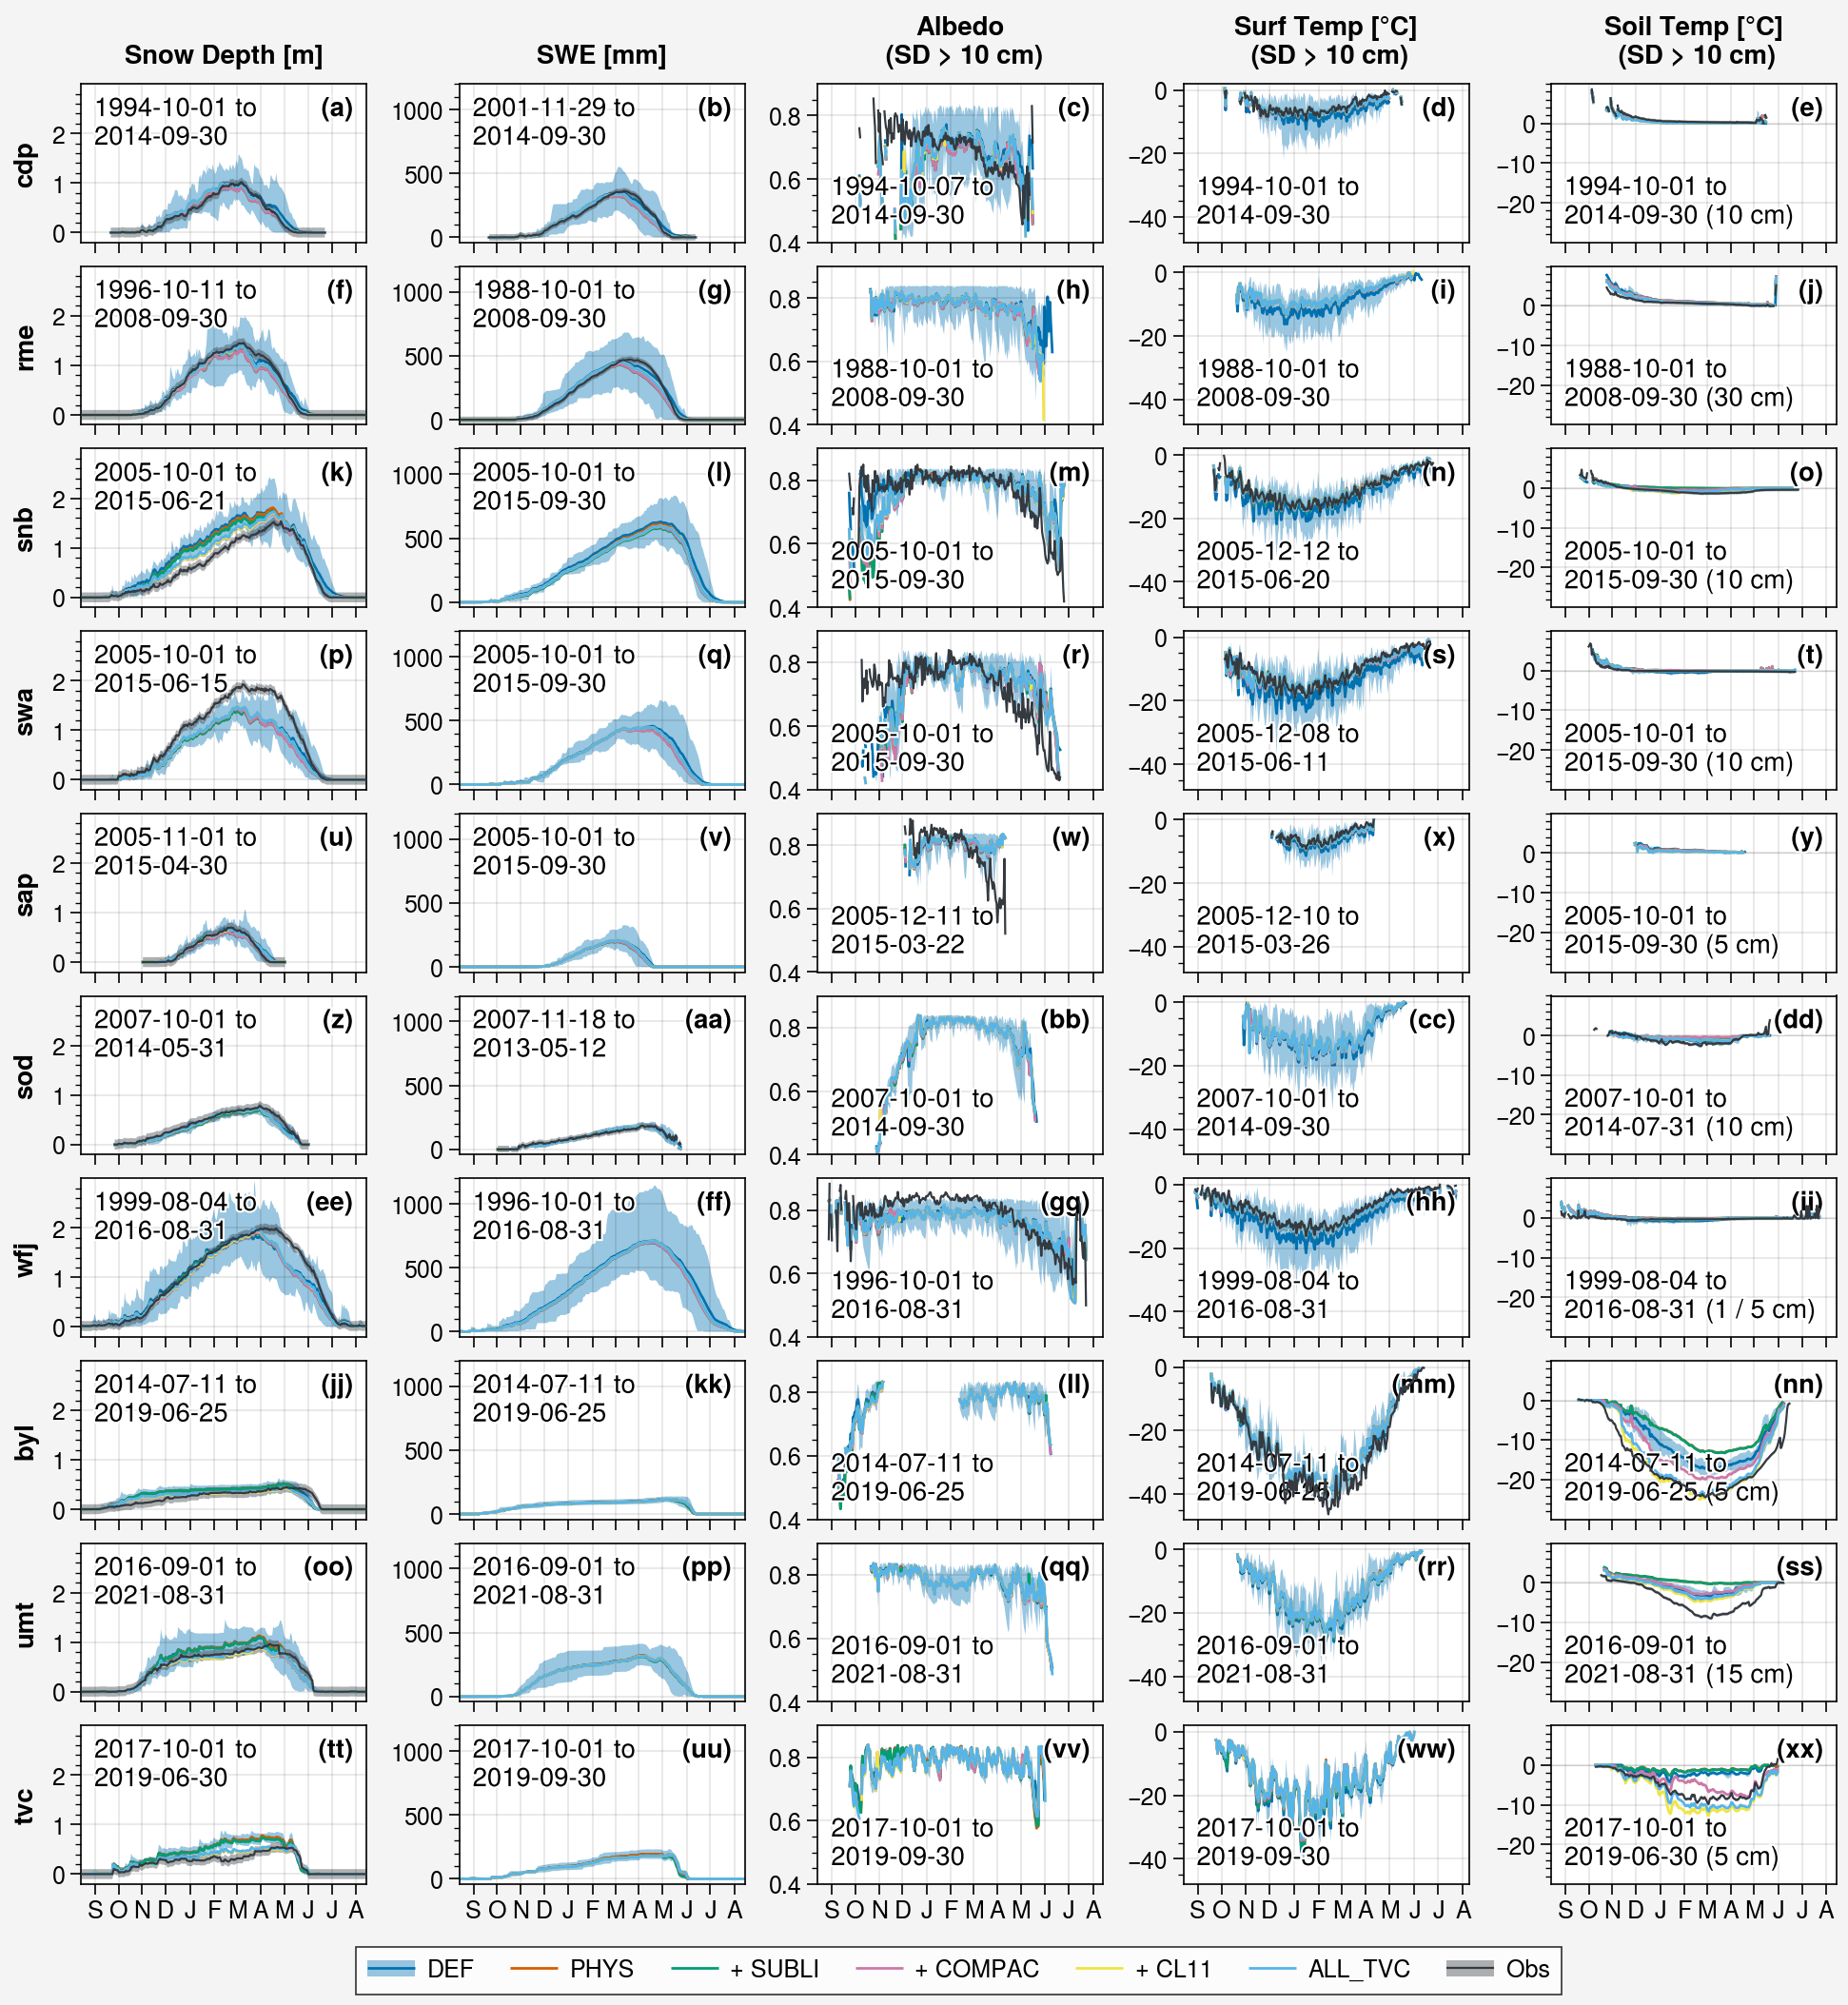

In [ ]:
import warnings
warnings.filterwarnings("ignore")

color_obs = 'gray8'

# Shifted DOY tick positions (non-leap year, shift = -140)
# These are the first DOY of each corresponding month in the shifted calendar
xticks = [
    19,   # Sep
    49,   # Oct
    79,   # Nov
    109,  # Dec
    140,  # Jan
    171,  # Feb
    200,  # Mar
    230,  # Apr
    260,  # May
    291,  # Jun
    321,  # Jul
    352   # Aug (closing)
]

# Corresponding month initials
xlabels = ['S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A']

# fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0)
fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0, hspace=1, refaspect=1.8)

# for i, site in enumerate([cdp]):
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):

    doy = 140
    period = site.period_used

    # Snow depth
    ax = axs[i*5+0]
    if site.name in ['snb', 'swa']:
        # Fill snow depth gaps for better visualization of seasonal cycle (intended for plotting, not necessarily for metrics)
        # Works only for snd_auto covering the whole period, which is the case for these 2 sites
        snd_obs_filled = fill_snowdepth_gaps(ds_d_Obs_list[i].snd_auto, long_gap_days=50)
    else:
        snd_obs_filled = ds_d_Obs_list[i].snd_auto
    mask_obs = ~snd_obs_filled.sel(time=period).isnull()
    
    shadedata = ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
    h1 = ax.plot(ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
    h_exps = []
    for j, exp in enumerate(label_exps[1:]):
        h = ax.plot(ds_d_SnowMIP_list[j+1][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = ax.plot(ds_d_Paul_list[i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
    #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
    
    obs = snd_obs_filled.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
    shadedata = np.concatenate((np.expand_dims(obs.values+0.1, axis=0), np.expand_dims(obs.values-0.1, axis=0),), axis=0)
    h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.8, zorder=10)
    ax.format(ylabel='', ylim=(-0.2,3), yticks=[0, 1, 2],
              ultitle=str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
              str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[-1].values)[:10])    
    # ax.legend(h1+h_exps+h_paul+h_obs, loc='ul', ncols=1)
    
    # Snow Water Equivalent
    ax = axs[i*5+1]

    if 'snw_auto' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].snw_auto.sel(time=period).isnull()
        
        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        
        obs = ds_d_Obs_list[i].snw_auto.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+25, axis=0), np.expand_dims(obs.values-25, axis=0),), axis=0)
        h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.8, zorder=10)
        ax.format(ylabel='', ylim=(-40,1200),
                  ultitle=str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[-1].values)[:10]) 

    else:
        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        
        ax.format(ylabel='', ylim=(-40,1200), ultitle=period.start+' to\n'+ period.stop)


    # Albedo (need to add a condition albs > 0.4 because a few values are 0 in the model -> bug? (e.g., at Saporo)
    # + low values are observed in the begining of the season (probably due to not full SCF coveraged)
    ax = axs[i*5+2]
    lim_alb = 0.4
    lim_alb_sup = 0.9

    if 'albs' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].albs.where(ds_d_Obs_list[i].albs > lim_alb).where(ds_d_Obs_list[i].albs < lim_alb_sup)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).sel(time=period).isnull()
        
        shadedata = ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                     .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albs.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albs > lim_alb) \
                        .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albs.sel(time=period).where(ds_d_Paul_list[i].albs > lim_alb) \
        #                     .where(ds_d_Paul_list[i].albs < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        if site not in ['umt', 'byl']:
            obs = ds_d_Obs_list[i].albs.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
            h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.8, zorder=10)
            ax.format(ylabel='', ylim=(0.4,0.9),
                      lltitle=str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[-1].values)[:10]) 

    else:
        shadedata = ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albs.sel(time=period).where(ds_d_SnowMIP_list[0][i].albs > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albs.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albs > lim_alb) \
                        .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albs.sel(time=period).where(ds_d_Paul_list[i].albs > lim_alb) \
        #                      .where(ds_d_SnowMIP_list[0][i].albs < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=1)
        
        ax.format(ylabel='', ylim=(0.4,0.9), lltitle=period.start+' to\n'+ period.stop)
    
    
    # Surface temperature
    # Add condition on ts <= 0 on obs to avoid melting pachy areas to be counted
    ax = axs[i*5+3]

    if 'ts' in list(ds_d_Obs_list[i].keys()) and ds_d_Obs_list[i].ts.notnull().sum() != 0:
        mask_obs = ~ds_d_Obs_list[i].ts.sel(time=period).where(ds_d_Obs_list[i].ts <= 0)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()
        
        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)
        
        obs = ds_d_Obs_list[i].ts.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.8, zorder=10)
        ax.format(ylabel='', ylim=(-48,2),
                  lltitle=str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[-1].values)[:10]) 

    else:
        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)
        
        ax.format(ylabel='', ylim=(-48,2), lltitle=period.start+' to\n'+ period.stop)

    
    # Soil temperature
    ax = axs[i*5+4]

    if 'tsl' in list(ds_d_Obs_list[i].keys()):
        
        # Get the first soil layer from obs (except for byl)
        if site.name in ['byl', 'tvc']:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[1].values.item(0) # 0.05 instead of 0.02
        else:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[0].values.item(0)

        # For wfj (otherwise NaN so take the first model level)
        if obs_sdepth < 0.01: 
            model_sdepth = 0.05
        else:
            model_sdepth = obs_sdepth
        mask_obs = ~ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        # Interp model on the first soil layer obs
        if obs_sdepth < 0.01: 
            ds_d_interp = ds_d_SnowMIP_list[0][i]
        else:
            ds_d_interp = ds_d_SnowMIP_list[0][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
        
        shadedata = ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            if obs_sdepth < 0.01: 
                ds_d_interp = ds_d_SnowMIP_list[j+1][i]
            else:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
            
            h = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     if obs_sdepth < 0.01: 
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     else:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)

        obs = ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+0.4, axis=0), np.expand_dims(obs.values-0.4, axis=0),), axis=0)
        h_obs = ax.plot(obs, label='Obs', shadedata=shadedata, color=color_obs, lw=0.8, zorder=10)
        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        if site.name == 'byl':
            ylim=(-30, 10)
        else:
            ylim=(-30, 10)
            # ylim=(-5, 10)
        if obs_sdepth != model_sdepth: 
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' / '+str(round(model_sdepth*100))+' cm)') 
        else:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' cm)')

    else:
        model_sdepth = 0.05 # first level
        
        shadedata = ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15, shadedata=shadedata, label=label_exps[0], zorder=1, lw=1)
        h_exps = []
        for j, exp in enumerate(label_exps[1:]):            
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15, label=exp, lw=1)
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=1)

        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20], lltitle=period.start+' to\n'+ period.stop+' ('+\
                     str(round(model_sdepth*100))+' cm)')
    
    
for ax in axs:
    # ax.format(xlim=(40,350))
    ax.format(xticks=xticks, xticklabels=xlabels, xtickminor=False, xlabel='')
    
fig.format(abc='(a)', abcloc='ur', 
           collabels=['Snow Depth [m]', 'SWE [mm]', 'Albedo\n (SD > 10 cm)', 'Surf Temp [°C]\n (SD > 10 cm)', 
                      'Soil Temp [°C]\n (SD > 10 cm)'],
           rowlabels=[site.name for site in SnowMIP_sites+SnowArctic_sites])
# fig.legend(h1+h_exps+h_paul+h_obs, loc='b', ncols=2)
fig.legend(h1+h_exps+h_obs, loc='b', ncols=8)

# fig.save('img/paper_ac_all_albedo_v4_correct_SH.jpg')
# fig.save('img/paper_ac_all_albedo_v4_correct_SH.png')
# fig.save('img/paper_ac_all_albedo_v4_correct_SH.pdf')


## Metrics

## Time series

In [16]:
def mb(simu, obs):
    return (simu-obs).mean().values.item(0)

def rmb(simu, obs):
    return ((simu-obs).mean()/np.abs(obs.mean())).values.item(0)*100
    
def mab(simu, obs):
    return (np.abs(simu-obs)).mean().values.item(0)

def rmab(simu, obs):
    return ((np.abs(simu-obs)).mean()/np.abs(obs.mean())).values.item(0)*100
    
def rmse(simu, obs):
    return np.sqrt(((simu-obs)**2).mean()).values.item(0)

def rrmse(simu, obs):
    return (np.sqrt(((simu-obs)**2).mean())/np.abs(obs.mean())).values.item(0)*100
    
def corr(simu, obs):
    return xr.corr(simu, obs).values.item(0)

In [17]:
def mb_a(simu, obs):
    return (simu-obs).mean()

def rmb_a(simu, obs):
    return ((simu-obs).mean()/np.abs(obs.mean()))*100
    
def mab_a(simu, obs):
    return (np.abs(simu-obs)).mean()

def rmab_a(simu, obs):
    return ((np.abs(simu-obs)).mean()/np.abs(obs.mean()))*100
    
def rmse_a(simu, obs):
    return np.sqrt(((simu-obs)**2).mean())

def rrmse_a(simu, obs):
    return (np.sqrt(((simu-obs)**2).mean())/np.abs(obs.mean()))*100
    
def corr_a(simu, obs):
    r, _ = stats.pearsonr(simu, obs)
    return r

In [18]:
# Can be negative if rmse > std
def calculate_score(std_deviation, rmse):
    return (std_deviation - rmse) / std_deviation

In [19]:
['Obs'] + [site.name for site in SnowMIP_sites]

['Obs', 'cdp', 'rme', 'snb', 'swa', 'sap', 'sod', 'wfj']

In [20]:
exps

['DEF',
 'BUG_CORRECT_TSNBT_OP1_EZERO',
 'PHYS_ALL_SUBLI_v2',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
 'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne']

In [21]:
df_metrics_list = []
column_indexes = ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']

for site in SnowMIP_sites+SnowArctic_sites:
    row_indexes = [['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD'], 
                   # ['Obs', 'CLASS']+exps]
                   ['Obs']+exps]
    rows = pd.MultiIndex.from_product(row_indexes)
    
    df_metrics = pd.DataFrame(index=rows, columns=column_indexes)
    df_metrics_list.append(df_metrics)
    
df_metrics_list[0]

mb  rmb  nmb  mab  \
snd_auto Obs                                           NaN  NaN  NaN  NaN   
         DEF                                           NaN  NaN  NaN  NaN   
         BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN  NaN  NaN   
...                                                    ...  ...  ...  ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  NaN  NaN  NaN  NaN   

                                                      rmab rmse rrmse nrmse  \
snd_auto Obs                                           NaN  NaN   NaN   NaN   
         DEF                                           NaN  NaN   NaN   NaN   
         BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN   NaN   
...                                                    ...  ...   ...   ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  NaN  NaN   NaN   NaN   

                                                         r stdd score  
snd_auto Obs                                           NaN  NaN   NaN  
         DEF                                           NaN  NaN   NaN  
         BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN  
...                                                    ...  ...   ...  
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  NaN  NaN   NaN  

[63 rows x 11 columns]

In [22]:
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    period = site.period_used
    for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl']:

        arr1 = ['Obs']+exps
        arr2 = [ds_d_Obs_list[i]]+[ds_d_SnowMIP_list[j][i] for j in range(len(exps))]
            
        for exp, ds_simu in zip(arr1, arr2):

            # We are going to make a common mask based on snd_auto so the comparison will be on the same period (auto/man)
            mask_obs_snd = ~ds_d_Obs_list[i].snd_auto.where(ds_d_Obs_list[i].snd_auto > 0.1).sel(time=period).isnull()
            if exp == 'Obs':
                if var == 'snd_auto':
                    obs = ds_d_Obs_list[i].snd_auto.where(mask_obs_snd).sel(time=period)
                    simu = obs
                elif var == 'snd_man':
                    if 'snd_man' in list(ds_d_Obs_list[i].keys()):
                        mask_obs = ~ds_d_Obs_list[i].snd_man.where(ds_d_Obs_list[i].snd_man > 0.1).sel(time=period).isnull()
                        obs = ds_d_Obs_list[i].snd_man.where(mask_obs_snd).where(mask_obs).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'snw_auto':
                    if 'snw_auto' in list(ds_d_Obs_list[i].keys()):
                        obs = ds_d_Obs_list[i].snw_auto.where(mask_obs_snd).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'snw_man':
                    if 'snw_man' in list(ds_d_Obs_list[i].keys()):
                        obs = ds_d_Obs_list[i].snw_man.where(mask_obs_snd).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'albs':
                    if 'albs' in list(ds_d_Obs_list[i].keys()):
                        mask_obs = ~ds_d_Obs_list[i].albs.where(ds_d_Obs_list[i].albs > 0.4)\
                                    .where(ds_d_Obs_list[i].albs < 0.9).sel(time=period).isnull()
                        obs = ds_d_Obs_list[i].albs.where(mask_obs_snd).where(mask_obs).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'ts':
                    if 'ts' in list(ds_d_Obs_list[i].keys()):
                        mask_obs = ~ds_d_Obs_list[i].ts.where(ds_d_Obs_list[i].ts <= 0).sel(time=period).isnull()
                        obs = ds_d_Obs_list[i].ts.where(mask_obs_snd).where(mask_obs).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'tsl':
                    if 'tsl' in list(ds_d_Obs_list[i].keys()):
                        # Get the first soil layer from obs
                        if site.name in ['byl', 'tvc']:
                            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[1].values.item(0)
                        else:
                            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[0].values.item(0) 
                        obs = ds_d_Obs_list[i].tsl.where(mask_obs_snd).sel(time=period, sdepth=obs_sdepth)
                        simu = obs
                    else:
                        pass
                else:
                    raise ValueError(var+" is not supported.")
                    
            # Model
            else:
                mask_simu_snd = ~ds_simu.snd.where(ds_simu.snd > 0.1).sel(time=period).isnull()
                if var in ['snd_auto', 'snd_man']:
                    simu = ds_simu.snd.where(obs.notnull()).where(mask_simu_snd).sel(time=period)
                elif var in ['snw_auto', 'snw_man']:
                    simu = ds_simu.snw.where(obs.notnull()).where(mask_simu_snd).sel(time=period)
                elif var == 'albs':
                    simu = ds_simu['albs'].where(ds_simu.albs > 0.4).where(ds_simu.albs < 0.9).where(obs.notnull())\
                            .where(mask_simu_snd).sel(time=period)
                elif var == 'ts':
                    simu = ds_simu[var].where(obs.notnull()).where(mask_simu_snd).sel(time=period)-273.15
                elif var == 'tsl':
                    if 'tsl' in list(ds_d_Obs_list[i].keys()):
                        # Interp model on the first soil layer obs
                        if obs_sdepth < 0.01: 
                            ds_d_interp = ds_simu[var]
                            model_sdepth = 0.05
                        else:
                            ds_d_interp = ds_simu[var].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
                            model_sdepth = obs_sdepth
                        simu = ds_d_interp.where(obs.notnull()).where(mask_simu_snd).sel(time=period, layer=model_sdepth)-273.15
                    else:
                        pass
                else:
                    raise ValueError(var+" is not supported.")

            if var in list(ds_d_Obs_list[i].keys()):
                # Remove albedo for Arctic sites because suspect wrong values
                if not (site.name in ['byl', 'umt', 'umf'] and var == 'albs'):
                    df_metrics_list[i].loc[(var, exp), 'mb'] = mb(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rmb'] = rmb(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'nmb'] = mb(simu, obs)/obs.std().values.item(0)
                    df_metrics_list[i].loc[(var, exp), 'mab'] = mab(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rmab'] = rmab(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rmse'] = rmse(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rrmse'] = rrmse(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'nrmse'] = rmse(simu, obs)/obs.std().values.item(0)
                    df_metrics_list[i].loc[(var, exp), 'r'] = corr(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'stdd'] = simu.std().values.item(0)
                    df_metrics_list[i].loc[(var, exp), 'score'] = calculate_score(obs.std().values.item(0), rmse(simu, obs))

            
df_metrics_list[0]

mb       rmb  \
snd_auto Obs                                                0.0       0.0   
         DEF                                           0.056881  8.227255   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.022213 -3.212943   
         PHYS_ALL_SUBLI_v2                            -0.022517 -3.256914   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.023873 -3.452994   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN       NaN   
         PHYS_ALL_SUBLI_v2                                  NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN       NaN   

                                                            nmb       mab  \
snd_auto Obs                                                0.0       0.0   
         DEF                                            0.14453  0.141662   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.056442  0.140857   
         PHYS_ALL_SUBLI_v2                            -0.057215  0.140615   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.060659  0.141254   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN       NaN   
         PHYS_ALL_SUBLI_v2                                  NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN       NaN   

                                                            rmab      rmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           20.489998  0.183213   
         BUG_CORRECT_TSNBT_OP1_EZERO                   20.373589  0.185427   
         PHYS_ALL_SUBLI_v2                              20.33851  0.185483   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   20.431069  0.187682   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                           rrmse     nrmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           26.500015  0.465531   
         BUG_CORRECT_TSNBT_OP1_EZERO                   26.820189  0.471155   
         PHYS_ALL_SUBLI_v2                             26.828295  0.471298   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   27.146391  0.476886   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                              r      stdd  \
snd_auto Obs                                           0.999998  0.393558   
         DEF                                            0.89756  0.371758   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.882915  0.353226   
         PHYS_ALL_SUBLI_v2   

In [23]:
df_metrics_list[-2]

mb        rmb  \
snd_auto Obs                                                0.0        0.0   
         DEF                                           0.079428   11.02048   
         BUG_CORRECT_TSNBT_OP1_EZERO                    0.08025  11.134546   
         PHYS_ALL_SUBLI_v2                             0.065947   9.150031   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.078733  -10.92407   
...                                                         ...        ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN        NaN   
         PHYS_ALL_SUBLI_v2                                  NaN        NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN        NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN        NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN        NaN   

                                                            nmb       mab  \
snd_auto Obs                                                0.0       0.0   
         DEF                                           0.278808   0.19411   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.281694  0.192534   
         PHYS_ALL_SUBLI_v2                             0.231487  0.186879   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.276369  0.150617   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN       NaN   
         PHYS_ALL_SUBLI_v2                                  NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN       NaN   

                                                            rmab      rmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           26.932466  0.249819   
         BUG_CORRECT_TSNBT_OP1_EZERO                   26.713762  0.248438   
         PHYS_ALL_SUBLI_v2                             25.929246  0.243156   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   20.897951  0.207847   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                           rrmse     nrmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           34.662098  0.876919   
         BUG_CORRECT_TSNBT_OP1_EZERO                   34.470483  0.872071   
         PHYS_ALL_SUBLI_v2                              33.73755  0.853528   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   28.838464  0.729586   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                              r      stdd  \
snd_auto Obs                                                1.0  0.284883   
         DEF                                           0.731937  0.346083   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.745578    0.3523   
         PHYS_ALL

In [24]:
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    period = site.period_used
    for var in ['SCD']:
        
        arr1 = ['Obs']+exps
        arr2 = [ds_d_Obs_list[i]]+[ds_d_SnowMIP_list[j][i] for j in range(len(exps))]
            
        for exp, ds_simu in zip(arr1, arr2):

            mask = ds_d_Obs_list[i].snd_auto > 0.1
            obs = ds_d_Obs_list[i].snd_auto.where(mask).sel(time=period).notnull()\
                    .resample(time='AS-'+calendar.month_abbr[int(period.start[5:7])]).sum()
            obs = obs.where(obs > 0)
            if exp == 'Obs':
                simu = obs
            else:
                simu = ds_simu.snd.where(ds_simu.snd > 0.1).sel(time=period).notnull()\
                        .resample(time='AS-'+calendar.month_abbr[int(period.start[5:7])]).sum().where(obs.notnull())
    
            df_metrics_list[i].loc[(var, exp), 'mb'] = mb(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rmb'] = rmb(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'nmb'] = mb(simu, obs)/obs.std().values.item(0)
            df_metrics_list[i].loc[(var, exp), 'mab'] = mab(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rmab'] = rmab(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rmse'] = rmse(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rrmse'] = rrmse(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'nrmse'] = rmse(simu, obs)/obs.std().values.item(0)
            df_metrics_list[i].loc[(var, exp), 'r'] = corr(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'stdd'] = simu.std().values.item(0)
            df_metrics_list[i].loc[(var, exp), 'score'] = calculate_score(obs.std().values.item(0), rmse(simu, obs))
            
df_metrics_list[0]

mb       rmb  \
snd_auto Obs                                                0.0       0.0   
         DEF                                           0.056881  8.227255   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.022213 -3.212943   
         PHYS_ALL_SUBLI_v2                            -0.022517 -3.256914   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.023873 -3.452994   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                       10.0  7.215007   
         PHYS_ALL_SUBLI_v2                                  9.9  7.142857   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                       10.0  7.215007   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne               12.9  9.307359   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne      12.8  9.235209   

                                                            nmb       mab  \
snd_auto Obs                                                0.0       0.0   
         DEF                                            0.14453  0.141662   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.056442  0.140857   
         PHYS_ALL_SUBLI_v2                            -0.057215  0.140615   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.060659  0.141254   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                    0.43671      12.6   
         PHYS_ALL_SUBLI_v2                             0.432343      12.5   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    0.43671      12.7   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.563356      14.0   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.558989      13.8   

                                                            rmab       rmse  \
snd_auto Obs                                                 0.0        0.0   
         DEF                                           20.489998   0.183213   
         BUG_CORRECT_TSNBT_OP1_EZERO                   20.373589   0.185427   
         PHYS_ALL_SUBLI_v2                              20.33851   0.185483   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   20.431069   0.187682   
...                                                          ...        ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                    9.090909  18.096961   
         PHYS_ALL_SUBLI_v2                              9.018759  18.061008   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    9.163059   18.16315   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            10.10101  19.590814   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    9.95671  19.419063   

                                                           rrmse     nrmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           26.500015  0.465531   
         BUG_CORRECT_TSNBT_OP1_EZERO                   26.820189  0.471155   
         PHYS_ALL_SUBLI_v2                             26.828295  0.471298   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   27.146391  0.476886   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                    13.05697  0.790313   
         PHYS_ALL_SUBLI_v2                              13.03103  0.788743   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   13.104725  0.793204   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           14.134787  0.855551   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  14.010868  0.848051   

                                                              r       stdd  \
snd_auto Obs                                           0.999998   0.393558   
         DEF                                            0.89756   0.371758   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.882915   0.353226   
         PHYS

In [25]:
df_metrics_list[-2].loc[('albs')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BUG_CORRECT_TSNBT_OP1_EZERO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Menard plot
https://journals.ametsoc.org/view/journals/bams/102/1/BAMS-D-19-0329.1.xml

In [26]:
# For calculating the mean of each site
df_gather = df_metrics_list[0].copy()
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD']:
    for metric in ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']:
        # for exp in ['Obs', 'CLASS']+exps:
        for exp in ['Obs']+exps:
            array_gather = np.array([df_metrics_list[i].loc[(var, exp), metric] for i, site in enumerate(SnowMIP_sites)])
            df_gather.loc[(var, exp), metric] = array_gather

df_gather_Arctic = df_metrics_list[0].copy()
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD']:
    for metric in ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']:
        # for exp in ['Obs', 'CLASS']+exps:
        for exp in ['Obs']+exps:
            if exp == 'CLASS':
                array_gather = np.nan
            else:
                array_gather = np.array([df_metrics_list[i].loc[(var, exp), metric] for i, site in enumerate(SnowMIP_sites+SnowArctic_sites)])
            df_gather_Arctic.loc[(var, exp), metric] = array_gather

df_Arctic = df_metrics_list[0].copy()
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD']:
    for metric in ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']:
        # for exp in ['Obs', 'CLASS']+exps:
        for exp in ['Obs']+exps:
            if exp == 'CLASS':
                array_gather = np.nan
            else:
                array_gather = np.array([df_metrics_list[len(SnowMIP_sites)+i].loc[(var, exp), metric] for i, site in enumerate(SnowArctic_sites)])
            df_Arctic.loc[(var, exp), metric] = array_gather

In [27]:
df_gather.loc[('albs')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,"[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.9999996763203693, nan, 1.000000962907109, 1...","[0.0953909158706665, nan, 0.0912841334939003, ...","[1.0, nan, 1.0, 1.0, 1.0, nan, 1.0]"
DEF,"[0.007708612031905529, nan, 0.0106457369422284...","[1.1161577131266132, nan, 1.3690471915629792, ...","[0.08081075605099616, nan, 0.11662198604251238...","[0.07915240640515644, nan, 0.04930165359058967...","[11.460762139278254, nan, 6.340217756073788, 1...","[0.10523075163640354, nan, 0.07019383452276848...","[15.236739715391892, nan, 9.026962862217438, 1...","[1.1031527549130373, nan, 0.7689598601213529, ...","[0.4995041776224546, nan, 0.6500866221872559, ...","[0.1129054698100044, nan, 0.0607799660643865, ...","[-0.10315275491303744, nan, 0.2310401398786471..."
BUG_CORRECT_TSNBT_OP1_EZERO,"[-0.013495944446865768, nan, -0.00615057637234...","[-1.9541264274230006, nan, -0.7909672533467025...","[-0.14148039489592407, nan, -0.067378372745918...","[0.0803310701980615, nan, 0.05934575334226688,...","[11.631425117021713, nan, 7.631894098579169, 9...","[0.10669445787383847, nan, 0.09110813842143886...","[15.448675015793913, nan, 11.716552993116883, ...","[1.1184970486969388, nan, 0.9980720080727589, ...","[0.5217506593306016, nan, 0.47506803561980293,...","[0.1192265988132248, nan, 0.08635631760312837,...","[-0.11849704869693882, nan, 0.0019279919272410..."
PHYS_ALL_SUBLI_v2,"[-0.013809290987438388, nan, -0.00674725710769...","[-1.9994970021378906, nan, -0.8677006997422625...","[-0.14476526261852213, nan, -0.073914894620172...","[0.08029595664047472, nan, 0.05963105314373075...","[11.626340898491373, nan, 7.668583798321629, 9...","[0.10694759528636595, nan, 0.0914593629379094,...","[15.485327693903026, nan, 11.761720644777963, ...","[1.1211507333818693, nan, 1.0019196046158538, ...","[0.5187626341118903, nan, 0.46829632030766344,...","[0.11913164850843125, nan, 0.08597777834754942...","[-0.12115073338186935, nan, -0.001919604615853..."
PHYS_ALL_SUBLI_v2_COMPAC_v1,"[-0.014062934642457694, nan, -0.00562883966275...","[-2.036222980921576, nan, -0.7238716468261199,...","[-0.14742425433386747, nan, -0.061662848156715...","[0.0805874960317134, nan, 0.05728922778007006,...","[11.668553937474847, nan, 7.367423864101097, 9...","[0.10737777374992313, nan, 0.0842508442812791,...","[15.547614783736188, nan, 10.834701474969018, ...","[1.125660371009633, nan, 0.9229516790769431, 0...","[0.5174898561898861, nan, 0.5173243831390638, ...","[0.11940589444380284, nan, 0.07907684667030561...","[-0.12566037100963287, nan, 0.0770483209230568..."
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,"[-0.0003520709313681685, nan, -0.0033429539208...","[-0.05097761879671514, nan, -0.429905576444564...","[-0.0036908224242811075, nan, -0.0366214126471...","[0.0780440108208686, nan, 0.05564757162235593,...","[11.300273548663254, nan, 7.156306046290344, 9...","[0.10336432449322135, nan, 0.0807595738342646,...","[14.966493003891909, nan, 10.385722317733569, ...","[1.0835866659815427, nan, 0.8847054876153373, ...","[0.5249727895376222, nan, 0.5405161330582746, ...","[0.11538202004954966, nan, 0.0750417506272223,...","[-0.08358666598154271, nan, 0.1152945123846627..."
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,"[-0.00023305184892654133, nan, -0.002907673797...","[-0.03374441697949564, nan, -0.373928330879513...","[-0.00244312413608146, nan, -0.031853003207979...","[0.07790271285802046, nan, 0.05542339206121265...","[11.279814507472793, nan, 7.127476440575439, 9...","[0.10303899256731491, nan, 0.0807531477473179,...","[14.919387022046687, nan, 10.38489591968007, 1...","[1.0801761533248917, nan, 0.8846350910776176, ...","[0.525779985535398, nan, 0.5398947579872356, 0...","[0.11509225

In [28]:
df_gather_Arctic.loc[('albs')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,"[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.9999996763203693, nan, 1.000000962907109, 1...","[0.0953909158706665, nan, 0.0912841334939003, ...","[1.0, nan, 1.0, 1.0, 1.0, nan, 1.0, nan, nan, ..."
DEF,"[0.007708612031905529, nan, 0.0106457369422284...","[1.1161577131266132, nan, 1.3690471915629792, ...","[0.08081075605099616, nan, 0.11662198604251238...","[0.07915240640515644, nan, 0.04930165359058967...","[11.460762139278254, nan, 6.340217756073788, 1...","[0.10523075163640354, nan, 0.07019383452276848...","[15.236739715391892, nan, 9.026962862217438, 1...","[1.1031527549130373, nan, 0.7689598601213529, ...","[0.4995041776224546, nan, 0.6500866221872559, ...","[0.1129054698100044, nan, 0.0607799660643865, ...","[-0.10315275491303744, nan, 0.2310401398786471..."
BUG_CORRECT_TSNBT_OP1_EZERO,"[-0.013495944446865768, nan, -0.00615057637234...","[-1.9541264274230006, nan, -0.7909672533467025...","[-0.14148039489592407, nan, -0.067378372745918...","[0.0803310701980615, nan, 0.05934575334226688,...","[11.631425117021713, nan, 7.631894098579169, 9...","[0.10669445787383847, nan, 0.09110813842143886...","[15.448675015793913, nan, 11.716552993116883, ...","[1.1184970486969388, nan, 0.9980720080727589, ...","[0.5217506593306016, nan, 0.47506803561980293,...","[0.1192265988132248, nan, 0.08635631760312837,...","[-0.11849704869693882, nan, 0.0019279919272410..."
PHYS_ALL_SUBLI_v2,"[-0.013809290987438388, nan, -0.00674725710769...","[-1.9994970021378906, nan, -0.8677006997422625...","[-0.14476526261852213, nan, -0.073914894620172...","[0.08029595664047472, nan, 0.05963105314373075...","[11.626340898491373, nan, 7.668583798321629, 9...","[0.10694759528636595, nan, 0.0914593629379094,...","[15.485327693903026, nan, 11.761720644777963, ...","[1.1211507333818693, nan, 1.0019196046158538, ...","[0.5187626341118903, nan, 0.46829632030766344,...","[0.11913164850843125, nan, 0.08597777834754942...","[-0.12115073338186935, nan, -0.001919604615853..."
PHYS_ALL_SUBLI_v2_COMPAC_v1,"[-0.014062934642457694, nan, -0.00562883966275...","[-2.036222980921576, nan, -0.7238716468261199,...","[-0.14742425433386747, nan, -0.061662848156715...","[0.0805874960317134, nan, 0.05728922778007006,...","[11.668553937474847, nan, 7.367423864101097, 9...","[0.10737777374992313, nan, 0.0842508442812791,...","[15.547614783736188, nan, 10.834701474969018, ...","[1.125660371009633, nan, 0.9229516790769431, 0...","[0.5174898561898861, nan, 0.5173243831390638, ...","[0.11940589444380284, nan, 0.07907684667030561...","[-0.12566037100963287, nan, 0.0770483209230568..."
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,"[-0.0003520709313681685, nan, -0.0033429539208...","[-0.05097761879671514, nan, -0.429905576444564...","[-0.0036908224242811075, nan, -0.0366214126471...","[0.0780440108208686, nan, 0.05564757162235593,...","[11.300273548663254, nan, 7.156306046290344, 9...","[0.10336432449322135, nan, 0.0807595738342646,...","[14.966493003891909, nan, 10.385722317733569, ...","[1.0835866659815427, nan, 0.8847054876153373, ...","[0.5249727895376222, nan, 0.5405161330582746, ...","[0.11538202004954966, nan, 0.0750417506272223,...","[-0.08358666598154271, nan, 0.1152945123846627..."
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,"[-0.00023305184892654133, nan, -0.002907673797...","[-0.03374441697949564, nan, -0.373928330879513...","[-0.00244312413608146, nan, -0.031853003207979...","[0.07790271285802046, nan, 0.05542339206121265...","[11.279814507472793, nan, 7.127476440575439, 9...","[0.10303899256731491, nan, 0.0807531477473179,...","[14.919387022046687, nan, 10.384895919680

In [29]:
df_Arctic.loc[('SCD')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[1.0, 1.0, 1.0]","[25.460557731518765, 12.24744871391589, 5.5]","[1.0, 1.0, 1.0]"
DEF,"[10.6, -1.4, 12.0]","[4.483925549915398, -0.6666666666666666, 5.466...","[0.41633023564435845, -0.11430952132988163, 2....","[10.6, 11.4, 12.0]","[4.483925549915398, 5.428571428571429, 5.46697...","[15.614096195425466, 12.860793132618221, 12.64...","[6.604947629198589, 6.124187206008677, 5.76269...","[0.6132660706052042, 1.0500793620801556, 2.299...","[0.9248075045993703, 0.16726667951658136, 1.0]","[17.412639087743134, 6.2481997407253225, 1.5]","[0.38673392939479573, -0.050079362080155704, -..."
BUG_CORRECT_TSNBT_OP1_EZERO,"[7.4, -2.0, 11.0]","[3.1302876480541455, -0.9523809523809524, 5.01...","[0.29064563620455214, -0.16329931618554522, 2.0]","[10.6, 12.0, 11.0]","[4.483925549915398, 5.714285714285714, 5.01138...","[14.303845636750978, 13.341664064126334, 11.70...","[6.050696123837131, 6.353173363869683, 5.33243...","[0.5618040966574588, 1.0893423092245462, 2.128...","[0.8985210722451785, 0.08390645410391885, 1.0]","[17.88183435780569, 6.0332412515993425, 1.5]","[0.4381959033425412, -0.08934230922454618, -1...."
PHYS_ALL_SUBLI_v2,"[7.4, -2.8, 8.5]","[3.1302876480541455, -1.3333333333333333, 3.87...","[0.29064563620455214, -0.22861904265976327, 1....","[10.6, 12.4, 8.5]","[4.483925549915398, 5.904761904761905, 3.87243...","[14.303845636750978, 13.6088206689632, 8.63133...","[6.050696123837131, 6.480390794744381, 3.93227...","[0.5618040966574588, 1.1111555546667022, 1.569...","[0.8985210722451785, 0.08887142532082949, 1.0]","[17.88183435780569, 6.43117407632541, 4.0]","[0.4381959033425412, -0.11115555466670217, -0...."
PHYS_ALL_SUBLI_v2_COMPAC_v1,"[8.0, -2.2, 8.5]","[3.3840947546531304, -1.0476190476190477, 3.87...","[0.3142114985995158, -0.17962924780409975, 1.5...","[10.0, 12.2, 8.5]","[4.230118443316413, 5.809523809523808, 3.87243...","[14.366627996854376, 13.61616686149226, 10.700...","[6.077253805775962, 6.483888981662981, 4.87492...","[0.5642699640891717, 1.1117553687749837, 1.945...","[0.9145211222076634, 0.04783446031074605, -1.0]","[17.258041603843697, 6.144916598294887, 1.0]","[0.4357300359108283, -0.1117553687749837, -0.9..."
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,"[8.2, -2.2, 9.5]","[3.4686971235194584, -1.0476190476190477, 4.32...","[0.3220667860645037, -0.17962924780409975, 1.7...","[9.8, 12.2, 9.5]","[4.145516074450085, 5.809523809523808, 4.32801...","[14.553350129781116, 13.61616686149226, 11.510...","[6.156239479602841, 6.483888981662981, 5.24412...","[0.5716037442402477, 1.1117553687749837, 2.092...","[0.9299571686813226, 0.04783446031074605, -1.0]","[16.131955864060625, 6.144916598294887, 1.0]","[0.4283962557597522, -0.1117553687749837, -1.0..."
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,"[9.0, -1.6, 11.5]","[3.807106598984771, -0.7619047619047619, 5.239...","[0.35348793592445527, -0.13063945294843618, 2....","[9.4, 12.0, 11.5]","[3.976311336717428, 5.714285714285714, 5.23917...","[14.892951352905172, 13.175735273600482, 12.74...","[6.299894819333829, 6.2741596540954685, 5.8075...","[0.5849420703957525, 1.075794280210363, 2.3177...","[0.9267687389294289, 0.12356532548424673, nan]","[16.572265988693278, 6.343500610861482, 0.0]","[0.4150579296042474, -0.07579428021036308, -1...."


### RMSE

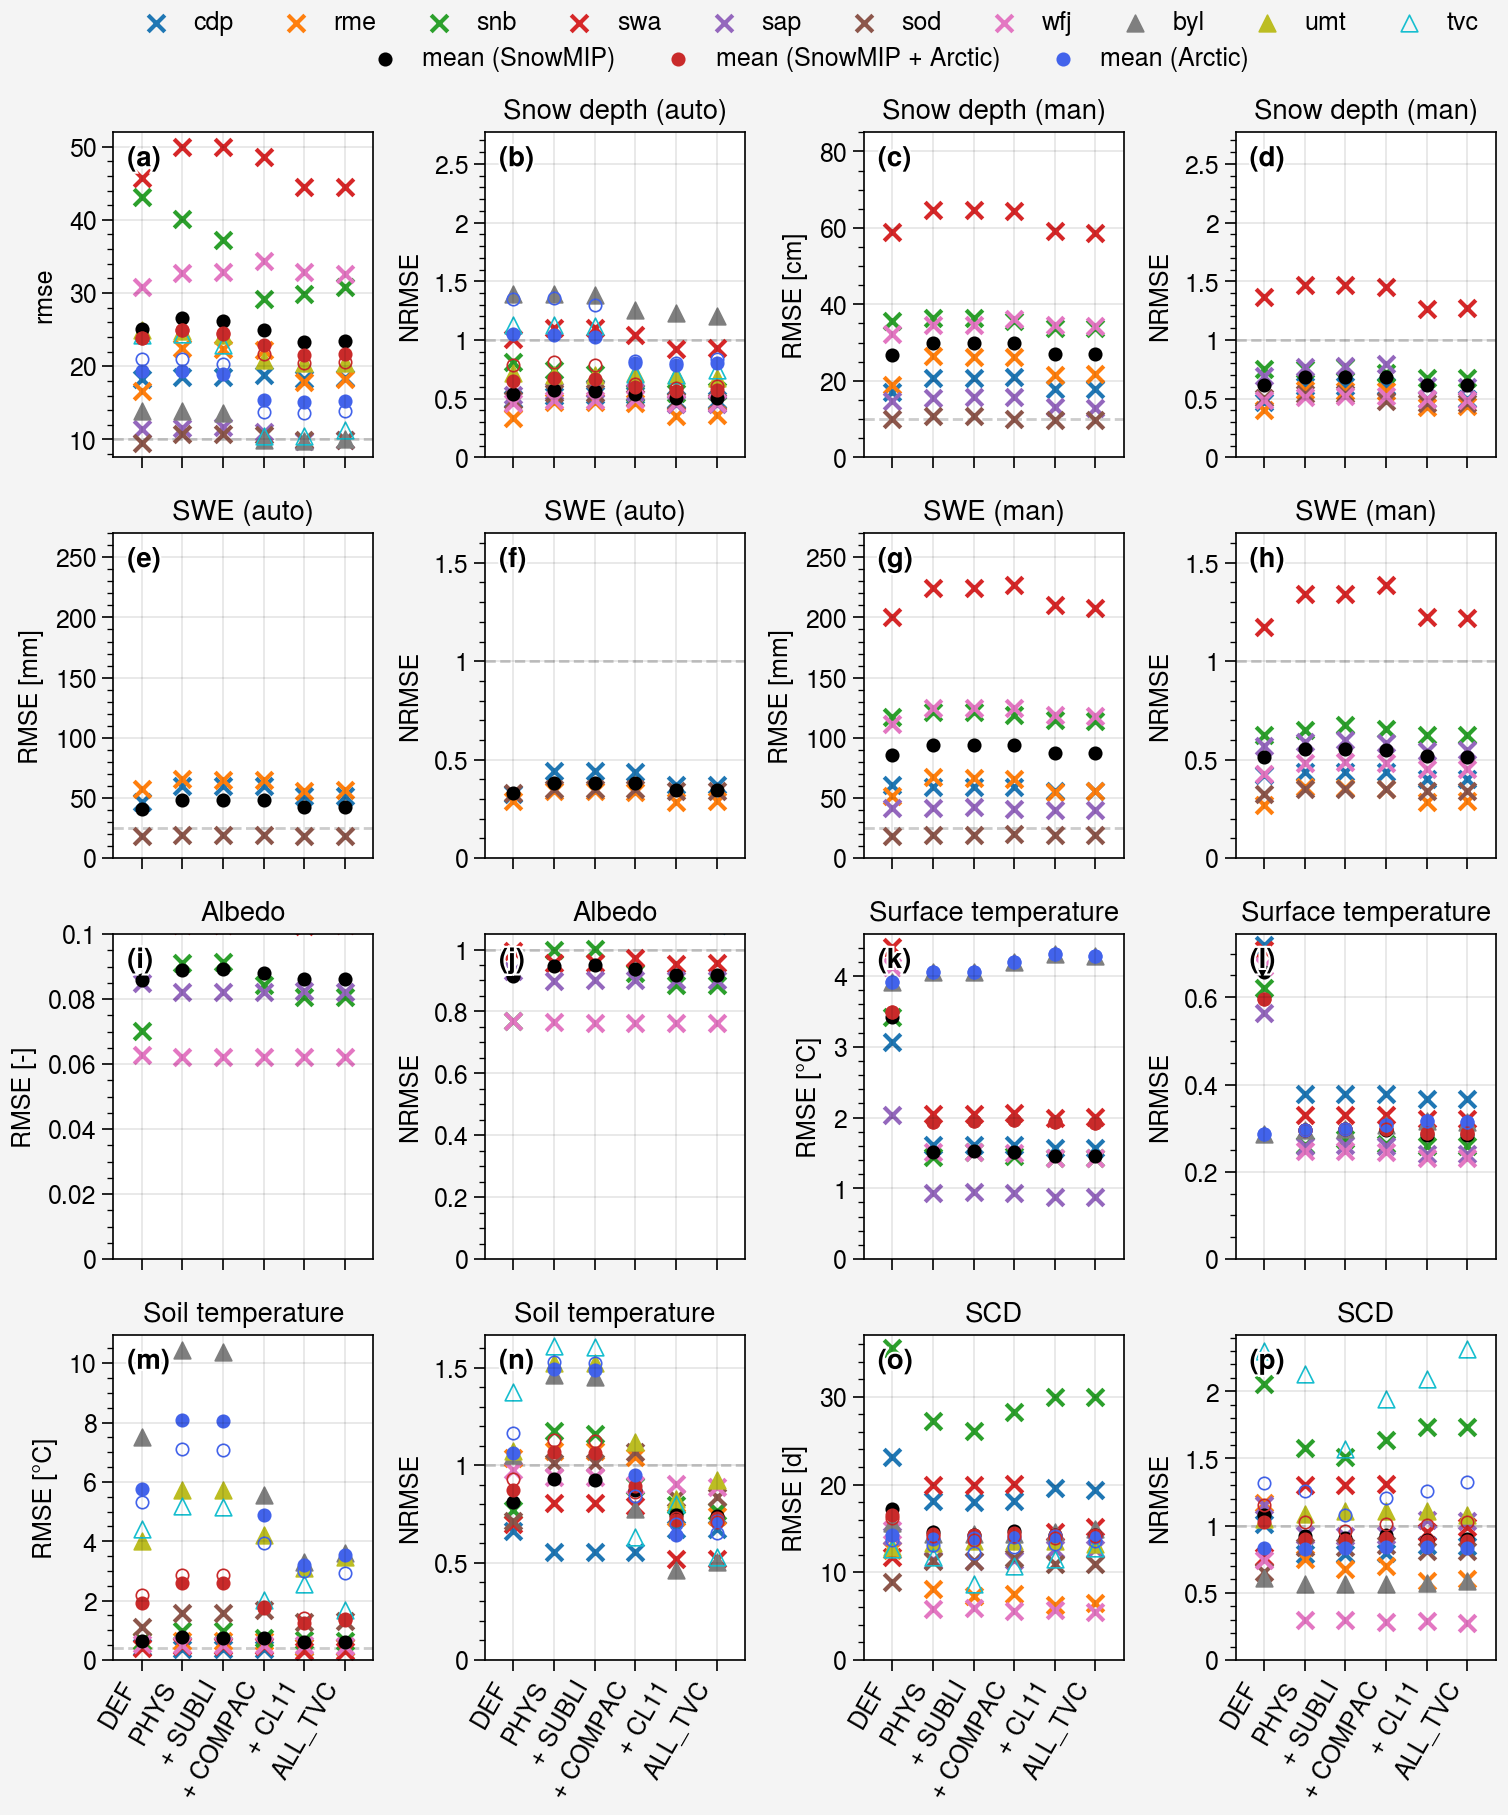

In [30]:
fig, axs = pplt.subplots(ncols=4, nrows=4, sharey=0, refaspect=0.8, refwidth=1.3)

colors = pplt.constructor.Cycle('default').by_key()['color']+pplt.constructor.Cycle('Accent').by_key()['color']
xrotation = 60
markers = ['x']*len(SnowMIP_sites) + ['^']*len(SnowArctic_sites)
marker_mean='.'; label_mean='mean (SnowMIP)'; color_mean='k'; marker_mean_size=80
marker_mean_arc='.'; label_mean_arc='mean (SnowMIP + Arctic)'; color_mean_arc='red9'; marker_mean_arc_size=80
marker_mean_arc_only='.'; label_mean_arc_only='mean (Arctic)'; color_mean_arc_only='indigo7'; marker_mean_arc_only_size=80

# Snow depth
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].rmse[1:]*100, marker=markers[i], label=site.name, 
                           edgecolors=colors[i], facecolors='none')
    else:
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].rmse[1:]*100, marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[0].scatter(df_gather.loc[('snd_auto')].rmse[1:].apply(np.mean)*100, 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
h_mean_arc_noTVC = axs[0].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                  marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, 
                                  markersize=marker_mean_arc_size)
h_mean_arc_only_noTVC = axs[0].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                       marker=marker_mean_arc_only, label=label_mean_arc_only, color=color_mean_arc_only, 
                                       markersize=marker_mean_arc_only_size)

h_mean_arc = axs[0].scatter(df_gather_Arctic.loc[('snd_auto')].rmse[1:].apply(np.mean)*100, marker=marker_mean_arc, 
                            label=label_mean_arc, edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
h_mean_arc_only = axs[0].scatter(df_Arctic.loc[('snd_auto')].rmse[1:].apply(np.mean)*100, marker=marker_mean_arc_only, 
                                 label=label_mean_arc_only, edgecolors=color_mean_arc_only, facecolors='none', 
                                 markersize=marker_mean_arc_only_size)

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[2].scatter(df_metrics_list[i].loc[('snd_man')].rmse[1:]*100, marker=markers[i], label=site.name, color=colors[i])
axs[2].scatter(df_gather.loc[('snd_man')].rmse[1:].apply(np.mean)*100, 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[2].scatter(df_gather_Arctic.loc[('snd_man')].rmse[1:].apply(np.nanmean)*100, 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[2].format(title='Snow depth (man)', ylabel='RMSE [cm]', xrotation=xrotation, ylim=(0, 85))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].rmse[1:]/df_metrics_list[i].loc[('snd_auto')].stdd[1:], 
                       marker=markers[i], label=site.name, edgecolors=colors[i], facecolors='none')
    else:
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].rmse[1:]/df_metrics_list[i].loc[('snd_auto')].stdd[1:], 
                       marker=markers[i], label=site.name, color=colors[i])
axs[1].scatter(df_gather.loc[('snd_auto')].nrmse[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[1].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc, 
               label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc_only, 
               label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[1].scatter(df_gather_Arctic.loc[('snd_auto')].nrmse[1:].apply(np.mean), marker=marker_mean_arc, label=label_mean_arc, 
               edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic.loc[('snd_auto')].nrmse[1:].apply(np.mean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
               edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

# axs[1].format(title='Snow depth (auto)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.58))
axs[1].format(title='Snow depth (auto)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 2.77))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[3].scatter(df_metrics_list[i].loc[('snd_man')].rmse[1:]/df_metrics_list[i].loc[('snd_man')].stdd[1:], 
                   marker=markers[i], label=site.name, color=colors[i])
axs[3].scatter(df_gather.loc[('snd_man')].nrmse[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[3].scatter(df_gather_Arctic.loc[('snd_man')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[3].format(title='Snow depth (man)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 2.77))


# Snow Water Equivalent
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[4].scatter(df_metrics_list[i].loc[('snw_auto')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[4].scatter(df_gather.loc[('snw_auto')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[4].scatter(df_gather_Arctic.loc[('snw_auto')].rmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[4].format(title='SWE (auto)', ylabel='RMSE [mm]', xrotation=xrotation, ylim=(0, 270))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[6].scatter(df_metrics_list[i].loc[('snw_man')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
axs[6].scatter(df_gather.loc[('snw_man')].rmse[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[6].scatter(df_gather_Arctic.loc[('snw_man')].rmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[6].format(title='SWE (man)', ylabel='RMSE [mm]', xrotation=xrotation, ylim=(0, 270))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[5].scatter(df_metrics_list[i].loc[('snw_auto')].rmse[1:]/df_metrics_list[i].loc[('snw_auto')].stdd[1:], 
                       marker=markers[i], label=site.name, color=colors[i])
axs[5].scatter(df_gather.loc[('snw_auto')].nrmse[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[5].scatter(df_gather_Arctic.loc[('snw_auto')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[5].format(title='SWE (auto)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.65))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[7].scatter(df_metrics_list[i].loc[('snw_man')].rmse[1:]/df_metrics_list[i].loc[('snw_man')].stdd[1:], 
                       marker=markers[i], label=site.name, color=colors[i])
axs[7].scatter(df_gather.loc[('snw_man')].nrmse[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[7].scatter(df_gather_Arctic.loc[('snw_man')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[7].format(title='SWE (man)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.65))


# Albedo
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[8].scatter(df_metrics_list[i].loc[('albs')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[8].scatter(df_gather.loc[('albs')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[8].scatter(df_gather_Arctic.loc[('albs')].rmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[8].format(title='Albedo', ylabel='RMSE [-]', xrotation=xrotation, ylim=(0, 0.1))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[9].scatter(df_metrics_list[i].loc[('albs')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[9].scatter(df_gather.loc[('albs')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[9].scatter(df_gather_Arctic.loc[('albs')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[9].format(title='Albedo', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.05))

# Surface temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].rmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[10].scatter(df_gather.loc[('ts')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[10].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[10].scatter(df_gather_Arctic.loc[('ts')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic.loc[('ts')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[10].format(title='Surface temperature', ylabel='RMSE [°C]', xrotation=xrotation, ylim=(0, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nrmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[11].scatter(df_gather.loc[('ts')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[11].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[11].scatter(df_gather_Arctic.loc[('ts')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic.loc[('ts')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[11].format(title='Surface temperature', ylabel='NRMSE', xrotation=xrotation, ylim=(0, None))

# Soil temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].rmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[12].scatter(df_gather.loc[('tsl')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[12].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[12].scatter(df_gather_Arctic.loc[('tsl')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic.loc[('tsl')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[12].format(title='Soil temperature', ylabel='RMSE [°C]', xrotation=xrotation, ylim=(0, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nrmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[13].scatter(df_gather.loc[('tsl')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[13].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[13].scatter(df_gather_Arctic.loc[('tsl')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic.loc[('tsl')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[13].format(title='Soil temperature', ylabel='NRMSE', xrotation=xrotation, ylim=(0, None))

# SCD
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].rmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[14].scatter(df_gather.loc[('SCD')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[14].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[14].scatter(df_gather_Arctic.loc[('SCD')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic.loc[('SCD')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[14].format(title='SCD', ylabel='RMSE [d]', xrotation=xrotation, ylim=(0, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nrmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[15].scatter(df_gather.loc[('SCD')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[15].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[15].scatter(df_gather_Arctic.loc[('SCD')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic.loc[('SCD')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[15].format(title='SCD', ylabel='NRMSE', xrotation=xrotation, ylim=(0, None))

x_min = -0.7
# x_max = 2.7
x_max = 5.7
for i, ax in enumerate(axs):
    # ax.format(xticklabels=['CLASS']+[exp[:-10] for exp in exps], xlim=(x_min, x_max))
    ax.format(xticklabels=label_exps, xlim=(x_min, x_max))
    if (i % 2) != 0:
        ax.hlines(1, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

# Snow Depth uncertainty
axs[0].hlines(10, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[2].hlines(10, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

# SWE uncertainty
axs[4].hlines(25, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[6].hlines(25, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

# Soil temp uncertainty
axs[12].hlines(0.4, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

    
fig.legend(h_list+[h_mean, h_mean_arc_noTVC, h_mean_arc_only_noTVC], loc='t', ncols=len(SnowMIP_sites)+len(SnowArctic_sites), center=True, frame=False)
fig.format(abc='(a)', abcloc='ul')
# fig.save('img/paper_rmse_all_v0.jpg')
# fig.save('img/paper_rmse_all_v0.png')
# fig.save('img/paper_rmse_all_v0.pdf')

### Scores

#### NRMSE

In [31]:
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].nrmse[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.68256387, 0.66124259, 0.65811127, 0.64867104, 0.60224239,
       0.60213434])

In [32]:
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.72920769, 0.72835354, 0.71724504, 0.66846353, 0.62600922,
       0.62765937])

In [33]:
score_array = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([1.03176609, 1.11111251, 1.05096809, 0.79364514, 0.76911918,
       0.78232535])

#### Score (no weights)

In [34]:
# No weight (I guess not good because raising the score because of lesser stations for SWE_auto
# -> raising artificially the score
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].score[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.31743613, 0.33875741, 0.34188873, 0.35132896, 0.39775761,
       0.39786566])

In [35]:
# No weight (I guess not good because raising the score because of lesser stations for SWE_auto
# -> raising artificially the score
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.27079231, 0.27164646, 0.28275496, 0.33153647, 0.37399078,
       0.37234063])

#### Score (weights)

In [36]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_gather.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.29902283, 0.3173209 , 0.32117202, 0.33058272, 0.37861267,
       0.37869942])

In [37]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.21483344, 0.21359023, 0.22942837, 0.29172416, 0.33677139,
       0.33399091])

In [38]:
df_Arctic

mb  \
snd_auto Obs                                                                             [0.0, 0.0, 0.0]   
         DEF                                           [0.09175622536718556, 0.07942769221931081, 0.1...   
         BUG_CORRECT_TSNBT_OP1_EZERO                   [0.08622985574405909, 0.08024979568375994, 0.1...   
         PHYS_ALL_SUBLI_v2                             [0.08219711690802849, 0.0659468386473439, 0.17...   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   [0.004274302932639527, -0.07873283657744604, 0...   
...                                                                                                  ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                                                   [7.4, -2.0, 11.0]   
         PHYS_ALL_SUBLI_v2                                                              [7.4, -2.8, 8.5]   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                                                    [8.0, -2.2, 8.5]   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                                            [8.2, -2.2, 9.5]   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne                                  [9.0, -1.6, 11.5]   

                                                                                                     rmb  \
snd_auto Obs                                                                             [0.0, 0.0, 0.0]   
         DEF                                           [29.977820757521222, 11.020479969187289, 56.59...   
         BUG_CORRECT_TSNBT_OP1_EZERO                   [28.17229184284616, 11.134545662265028, 56.649...   
         PHYS_ALL_SUBLI_v2                             [26.854749392678468, 9.150030600632068, 51.804...   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   [1.3964642362439557, -10.924069731539896, 13.2...   
...                                                                                                  ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                   [3.1302876480541455, -0.9523809523809524, 5.01...   
         PHYS_ALL_SUBLI_v2                             [3.1302876480541455, -1.3333333333333333, 3.87...   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   [3.3840947546531304, -1.0476190476190477, 3.87...   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           [3.4686971235194584, -1.0476190476190477, 4.32...   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  [3.807106598984771, -0.7619047619047619, 5.239...   

                                                                                                     nmb  \
snd_auto Obs                                                                             [0.0, 0.0, 0.0]   
         DEF                                           [0.8077353587115513, 0.27880784612804294, 1.53...   
         BUG_CORRECT_TSNBT_OP1_EZERO                   [0.7590864072965875, 0.2816936015845226, 1.539...   
         PHYS_ALL_SUBLI_v2                             [0.7235859740859151, 0.2314872247761131, 1.407...   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   [0.037626935924198676, -0.276368757197405, 0.3...   
...                                                                                                  ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                    [0.29064563620455214, -0.16329931618554522, 2.0]   
         PHYS_ALL_SUBLI_v2                             [0.29064563620455214, -0.22861904265976327, 1....   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   [0.3142114985995158, -0.17962924780409975, 1.5...   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           [0.3220667860645037, -0.17962924780409975, 1.7...   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  [0.35348793592445527, -0.13063945294843618, 2....   

                                                                                                     mab  \
snd_auto Obs                                                                             [0.0, 0.0, 0.0

In [39]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.18085667, -0.2739439 , -0.20176679,  0.10908894,  0.14011737,
        0.12386089])

In [40]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.120769  , -0.28002363, -0.25362486,  0.24463631,  0.31105961,
        0.31672591])

In [41]:
# # Best score?
# score_array = []
# weights = []
# for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
#     score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
#     # Weight per obs sites (give twice more weight to sn from auto/man)
#     # Make sense because other variable have smaller std and so higher NRMSE
#     # (which might give them too much importance)
#     weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
#     # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
#     #     weight = weight*0.5
#     weights.append(weight)
# score_array = np.average(np.array(score_array), axis=0, weights=weights)
# score_array

In [42]:
# Alternative score
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites and 0.5 for sn auto/man
    weight = np.nansum(df_gather.loc[(var)].score[1:]['DEF']*0+1)
    if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
        weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.23979385, 0.28092066, 0.28538911, 0.29467841, 0.34386587,
       0.34401243])

In [43]:
# Alternative score
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites and 0.5 for sn auto/man
    weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
        weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.16353066, 0.17534699, 0.19359472, 0.25589703, 0.30220828,
       0.2997133 ])

In [44]:
# Alternative score
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites and 0.5 for sn auto/man
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
        weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.15049423, -0.25936814, -0.1843822 ,  0.096209  ,  0.13067703,
        0.11730511])

### Mean bias

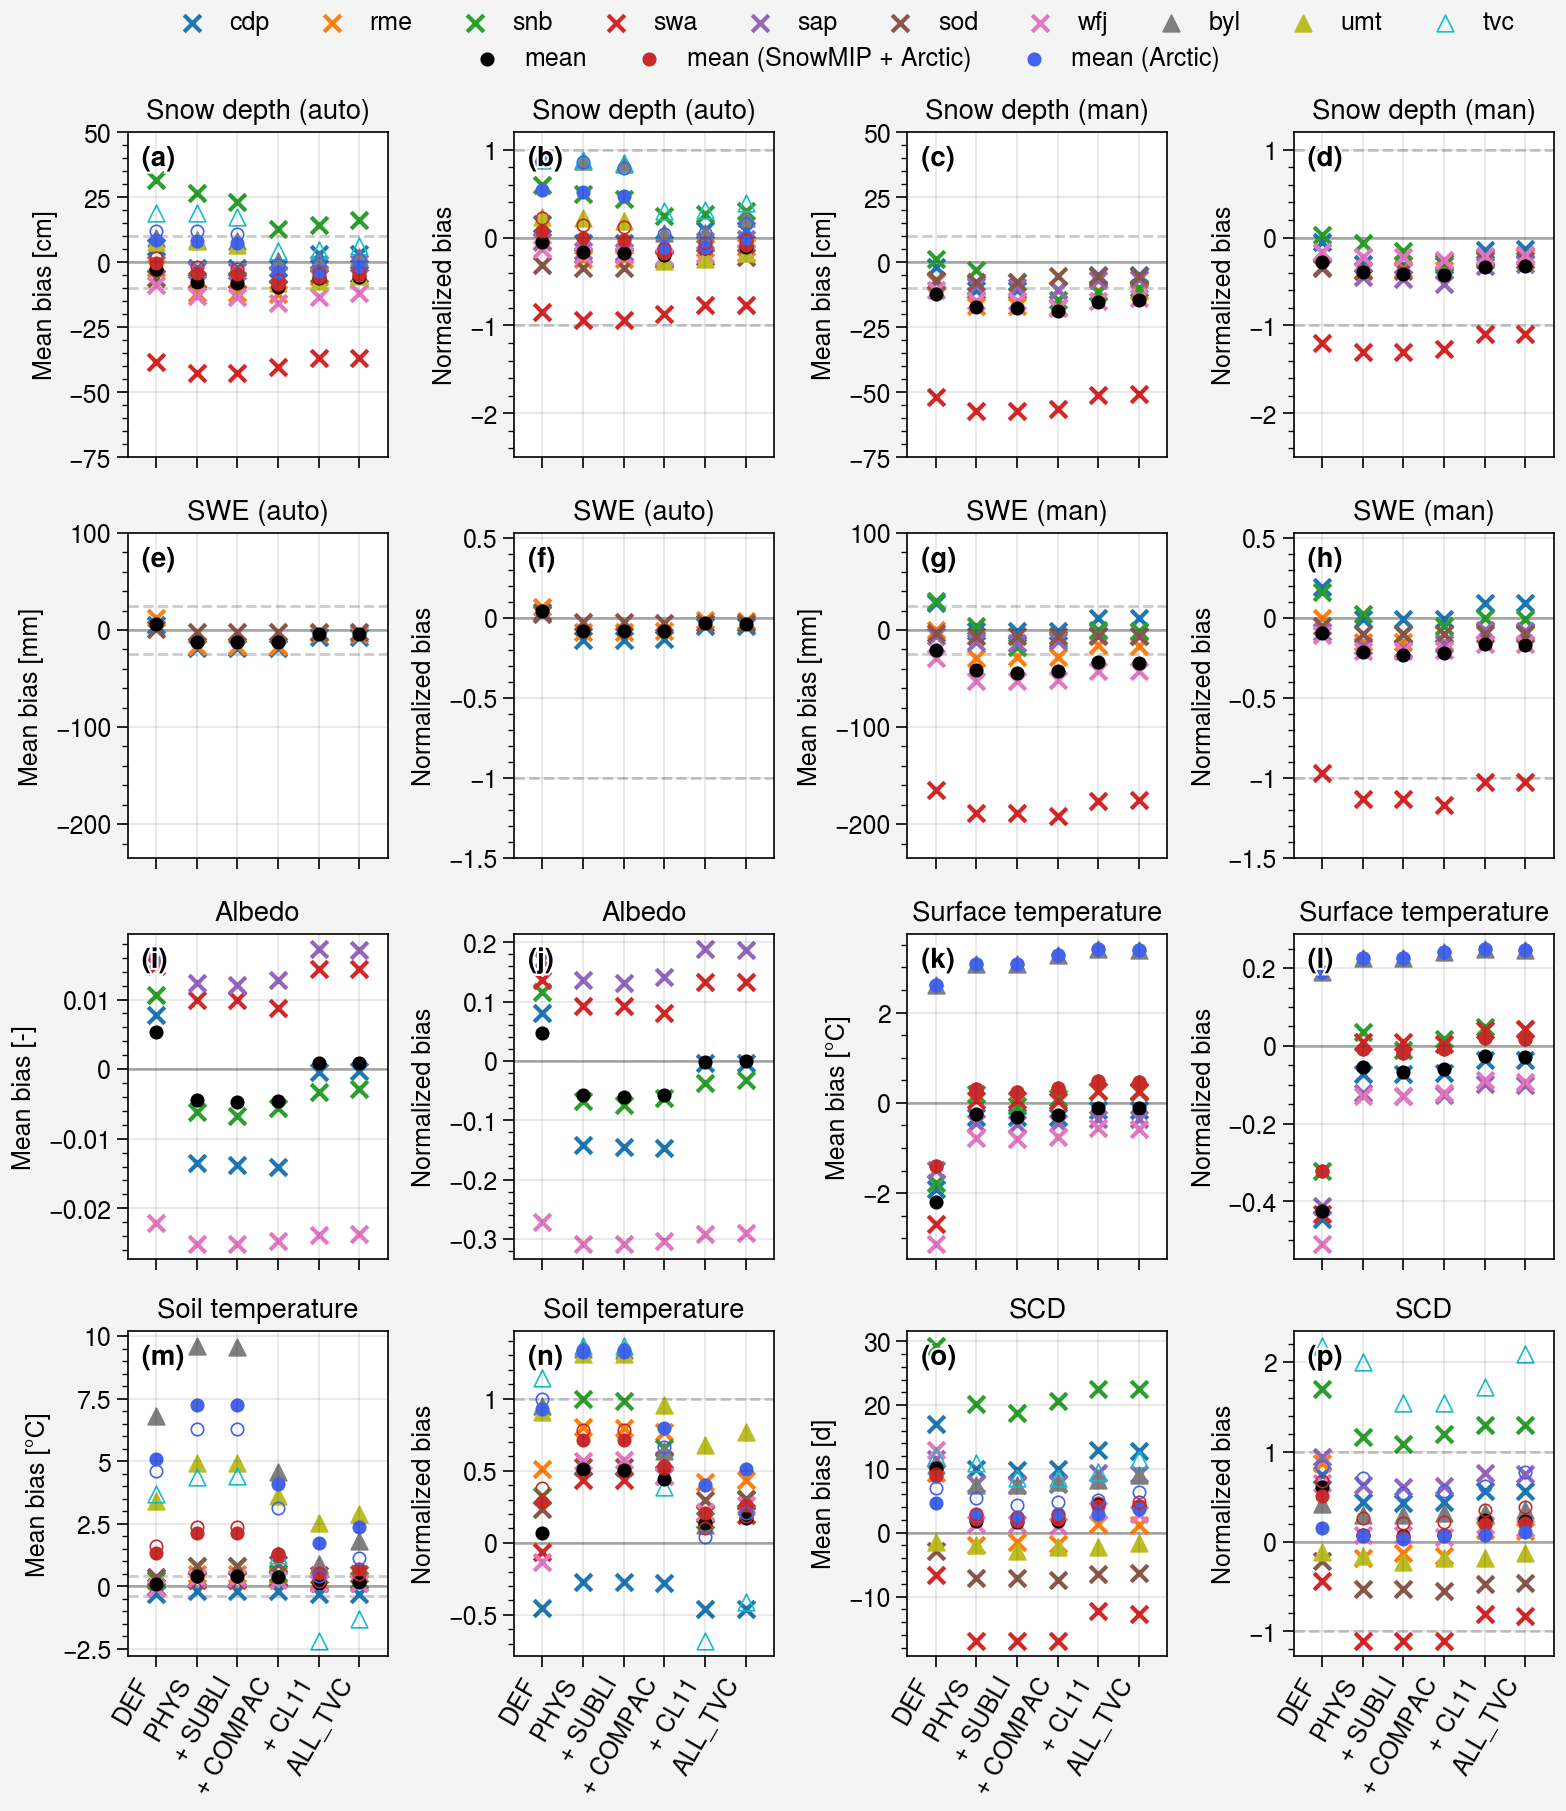

In [45]:
fig, axs = pplt.subplots(ncols=4, nrows=4, sharey=0, refaspect=0.8, refwidth=1.3)

colors = pplt.constructor.Cycle('default').by_key()['color']+pplt.constructor.Cycle('Accent').by_key()['color']
xrotation=60
markers = ['x']*len(SnowMIP_sites) + ['^']*len(SnowArctic_sites)
marker_mean='.'; label_mean='mean'; color_mean='k'; marker_mean_size=80
marker_mean_arc='.'; label_mean_arc='mean (SnowMIP + Arctic)'; color_mean_arc='red9'; marker_mean_arc_size=80
marker_mean_arc_only='.'; label_mean_arc_only='mean (Arctic)'; color_mean_arc_only='indigo7'; marker_mean_arc_only_size=80


# Snow depth
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].mb[1:]*100, marker=markers[i], label=site.name, 
                           edgecolors=colors[i], facecolors='none')
    else:
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].mb[1:]*100, marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[0].scatter(df_gather.loc[('snd_auto')].mb[1:].apply(np.mean)*100, 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
h_mean_arc_noTVC = axs[0].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                  marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
h_mean_arc_only_noTVC = axs[0].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                       marker=marker_mean_arc_only, label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

h_mean_arc = axs[0].scatter(df_gather_Arctic.loc[('snd_auto')].mb[1:].apply(np.mean)*100, marker=marker_mean_arc, 
                            label=label_mean_arc, edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
h_mean_arc_only = axs[0].scatter(df_Arctic.loc[('snd_auto')].mb[1:].apply(np.mean)*100, marker=marker_mean_arc_only, 
                                 label=label_mean_arc_only, edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[0].format(title='Snow depth (auto)', ylabel='Mean bias [cm]', xrotation=xrotation, ylim=(-75, 50))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[2].scatter(df_metrics_list[i].loc[('snd_man')].mb[1:]*100, marker=markers[i], label=site.name, color=colors[i])
axs[2].scatter(df_gather.loc[('snd_man')].mb[1:].apply(np.mean)*100, 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[2].scatter(df_gather_Arctic.loc[('snd_man')].mb[1:].apply(np.nanmean)*100, 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[2].format(title='Snow depth (man)', ylabel='Mean bias [cm]', xrotation=xrotation, ylim=(-75, 50))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].mb[1:]/df_metrics_list[i].loc[('snd_auto')].stdd[1:], 
                       marker=markers[i], label=site.name, edgecolors=colors[i], facecolors='none')
    else:
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].mb[1:]/df_metrics_list[i].loc[('snd_auto')].stdd[1:], 
                       marker=markers[i], label=site.name, color=colors[i])
axs[1].scatter(df_gather.loc[('snd_auto')].nmb[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[1].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc, 
               label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc_only, 
               label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)
                                 
axs[1].scatter(df_gather_Arctic.loc[('snd_auto')].nmb[1:].apply(np.mean), marker=marker_mean_arc, label=label_mean_arc, 
               edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic.loc[('snd_auto')].nmb[1:].apply(np.mean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
               edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[1].format(title='Snow depth (auto)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-2.5, 1.2))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[3].scatter(df_metrics_list[i].loc[('snd_man')].mb[1:]/df_metrics_list[i].loc[('snd_man')].stdd[1:], 
                   marker=markers[i], label=site.name, color=colors[i])
axs[3].scatter(df_gather.loc[('snd_man')].nmb[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[3].scatter(df_gather_Arctic.loc[('snd_man')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[3].format(title='Snow depth (man)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-2.5, 1.2))


# Snow Water Equivalent
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[4].scatter(df_metrics_list[i].loc[('snw_auto')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[4].scatter(df_gather.loc[('snw_auto')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[4].scatter(df_gather_Arctic.loc[('snw_auto')].mb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[4].format(title='SWE (auto)', ylabel='Mean bias [mm]', xrotation=xrotation, ylim=(-235, 100))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[6].scatter(df_metrics_list[i].loc[('snw_man')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
axs[6].scatter(df_gather.loc[('snw_man')].mb[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[6].scatter(df_gather_Arctic.loc[('snw_man')].mb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[6].format(title='SWE (man)', ylabel='Mean bias [mm]', xrotation=xrotation, ylim=(-235, 100))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[5].scatter(df_metrics_list[i].loc[('snw_auto')].mb[1:]/df_metrics_list[i].loc[('snw_auto')].stdd[1:], 
                   marker=markers[i], label=site.name, color=colors[i])
axs[5].scatter(df_gather.loc[('snw_auto')].nmb[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[5].scatter(df_gather_Arctic.loc[('snw_auto')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[5].format(title='SWE (auto)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-1.5, 0.53))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[7].scatter(df_metrics_list[i].loc[('snw_man')].mb[1:]/df_metrics_list[i].loc[('snw_man')].stdd[1:], 
                   marker=markers[i], label=site.name, color=colors[i])
axs[7].scatter(df_gather.loc[('snw_man')].nmb[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[7].scatter(df_gather_Arctic.loc[('snw_man')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[7].format(title='SWE (man)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-1.5, 0.53))


# Albedo
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[8].scatter(df_metrics_list[i].loc[('albs')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[8].scatter(df_gather.loc[('albs')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[8].scatter(df_gather_Arctic.loc[('albs')].mb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[8].format(title='Albedo', ylabel='Mean bias [-]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[9].scatter(df_metrics_list[i].loc[('albs')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[9].scatter(df_gather.loc[('albs')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[9].scatter(df_gather_Arctic.loc[('albs')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[9].format(title='Albedo', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

# Surface temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].mb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[10].scatter(df_gather.loc[('ts')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[10].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[10].scatter(df_gather_Arctic.loc[('ts')].mb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic.loc[('ts')].mb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[10].format(title='Surface temperature', ylabel='Mean bias [°C]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nmb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[11].scatter(df_gather.loc[('ts')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[11].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[11].scatter(df_gather_Arctic.loc[('ts')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic.loc[('ts')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[11].format(title='Surface temperature', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

# Soil temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].mb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[12].scatter(df_gather.loc[('tsl')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[12].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[12].scatter(df_gather_Arctic.loc[('tsl')].mb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic.loc[('tsl')].mb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[12].format(title='Soil temperature', ylabel='Mean bias [°C]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nmb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[13].scatter(df_gather.loc[('tsl')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[13].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[13].scatter(df_gather_Arctic.loc[('tsl')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic.loc[('tsl')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[13].format(title='Soil temperature', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

# SCD
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].mb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[14].scatter(df_gather.loc[('SCD')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[14].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[14].scatter(df_gather_Arctic.loc[('SCD')].mb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic.loc[('SCD')].mb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[14].format(title='SCD', ylabel='Mean bias [d]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nmb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[15].scatter(df_gather.loc[('SCD')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[15].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[15].scatter(df_gather_Arctic.loc[('SCD')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic.loc[('SCD')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[15].format(title='SCD', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

x_min = -0.7
x_max = 5.7
for ax in axs:
    # ax.format(xticklabels=['CLASS']+[exp[:-10] for exp in exps], xlim=(x_min, x_max))
    ax.format(xticklabels=label_exps, xlim=(x_min, x_max))
    ax.hlines(0, x_min, x_max, color='k', lw=1, alpha=0.3, zorder=0, ls='-')

# Obs uncertainties (base on Lejeune et al. (2019) at cdp)
axs[0].hlines([-10, 10], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[2].hlines([-10, 10], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

axs[4].hlines([-25, 25], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[6].hlines([-25, 25], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

axs[12].hlines([-0.4, 0.4], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

for i, ax in enumerate(axs):
    if (i % 2) != 0:
        ax.hlines([-1, 1], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

    
fig.legend(h_list+[h_mean, h_mean_arc_noTVC, h_mean_arc_only_noTVC], loc='t', ncols=len(SnowMIP_sites)+len(SnowArctic_sites), center=True, frame=False)
fig.format(abc='(a)', abcloc='ul')
# fig.save('img/paper_mb_all_v0.jpg')
# fig.save('img/paper_mb_all_v0.png')
# fig.save('img/paper_mb_all_v0.pdf')

In [46]:
# for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
for var in ['SCD']:
    print('###############')
    print('### SnowMIP ###')
    print('###############')
    print('MB')
    print('df_gather.loc[('+var+')].mb[1:]')
    print(df_gather.loc[(var)].mb[1:].apply(np.nanmean))
    
    print('\ndf_gather.loc[('+var+')].nmb[1:]')
    print(df_gather.loc[(var)].nmb[1:].apply(np.nanmean))

    print('\nRMSE')
    print('df_gather.loc[('+var+')]rmse[1:]')
    print(df_gather.loc[(var)].rmse[1:].apply(np.nanmean))
    
    print('\ndf_gather.loc[('+var+')].nrmse[1:]')
    print(df_gather.loc[(var)].nrmse[1:].apply(np.nanmean))
    
    
    print('\n########################')
    print('### SnowMIP + Arctic ###')
    print('########################')
    print('MB')
    print('df_gather_Arctic.loc[('+var+')].mb[1:]')
    print(df_gather_Arctic.loc[(var)].mb[1:].apply(np.nanmean))
    
    print('\ndf_gather_Arctic.loc[('+var+')].nmb[1:]')
    print(df_gather_Arctic.loc[(var)].nmb[1:].apply(np.nanmean))

    print('\nRMSE')
    print('df_gather_Arctic.loc[('+var+')]rmse[1:]')
    print(df_gather_Arctic.loc[(var)].rmse[1:].apply(np.nanmean))
    
    print('\ndf_gather_Arctic.loc[('+var+')].nrmse[1:]')
    print(df_gather_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean))


    print('\n##############')
    print('### Arctic ###')
    print('##############')
    print('MB')
    print('df_Arctic.loc[('+var+')].mb[1:]')
    print(df_Arctic.loc[(var)].mb[1:].apply(np.nanmean))
    
    print('\ndf_Arctic.loc[('+var+')].nmb[1:]')
    print(df_Arctic.loc[(var)].nmb[1:].apply(np.nanmean))

    print('\nRMSE')
    print('df_Arctic.loc[('+var+')]rmse[1:]')
    print(df_Arctic.loc[(var)].rmse[1:].apply(np.nanmean))
    
    print('\ndf_Arctic.loc[('+var+')].nrmse[1:]')
    print(df_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean))



###############
### SnowMIP ###
###############
MB
df_gather.loc[(SCD)].mb[1:]
DEF                                             10.092957
BUG_CORRECT_TSNBT_OP1_EZERO                      1.907463
PHYS_ALL_SUBLI_v2                                1.707463
PHYS_ALL_SUBLI_v2_COMPAC_v1                      1.874490
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne              4.425190
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     4.252041
Name: mb, dtype: float64

df_gather.loc[(SCD)].nmb[1:]
DEF                                             0.608817
BUG_CORRECT_TSNBT_OP1_EZERO                     0.071256
PHYS_ALL_SUBLI_v2                               0.061351
PHYS_ALL_SUBLI_v2_COMPAC_v1                     0.069521
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             0.237467
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    0.227009
Name: nmb, dtype: float64

RMSE
df_gather.loc[(SCD)]rmse[1:]
DEF                                             17.242428
BUG_CORRECT_TSNBT_OP1_EZERO                     14.549068

In [47]:
df_gather.loc[(var)].mb[1:].apply(np.nanmean)

DEF                                             10.092957
BUG_CORRECT_TSNBT_OP1_EZERO                      1.907463
PHYS_ALL_SUBLI_v2                                1.707463
PHYS_ALL_SUBLI_v2_COMPAC_v1                      1.874490
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne              4.425190
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     4.252041
Name: mb, dtype: float64

In [48]:
df_Arctic.loc[(var)].mb[1:]

DEF                                             [10.6, -1.4, 12.0]
BUG_CORRECT_TSNBT_OP1_EZERO                      [7.4, -2.0, 11.0]
PHYS_ALL_SUBLI_v2                                 [7.4, -2.8, 8.5]
PHYS_ALL_SUBLI_v2_COMPAC_v1                       [8.0, -2.2, 8.5]
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne               [8.2, -2.2, 9.5]
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     [9.0, -1.6, 11.5]
Name: mb, dtype: object

In [49]:
df_Arctic.loc[(var)].mb[1:]

DEF                                             [10.6, -1.4, 12.0]
BUG_CORRECT_TSNBT_OP1_EZERO                      [7.4, -2.0, 11.0]
PHYS_ALL_SUBLI_v2                                 [7.4, -2.8, 8.5]
PHYS_ALL_SUBLI_v2_COMPAC_v1                       [8.0, -2.2, 8.5]
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne               [8.2, -2.2, 9.5]
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     [9.0, -1.6, 11.5]
Name: mb, dtype: object

In [50]:
df_Arctic['mb'].apply(lambda x: x[:-1]).loc[(var)][1:]

DEF                                             [10.6, -1.4]
BUG_CORRECT_TSNBT_OP1_EZERO                      [7.4, -2.0]
PHYS_ALL_SUBLI_v2                                [7.4, -2.8]
PHYS_ALL_SUBLI_v2_COMPAC_v1                      [8.0, -2.2]
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne              [8.2, -2.2]
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     [9.0, -1.6]
Name: mb, dtype: object